In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

In [2]:
# params
h = 10
threshold = 0.8
fee_rate = 0.001  # 0.1%
qty = 0.001
window = 100  # window for local estimation

alpha_q = 100
alpha_imb = 0.02


gamma = 0.1  # risk aversion
k = 1.5  # execution intensity parameter

### Analytics


In [3]:
df = pd.read_csv("../data/raw/bookticker.csv")
df["volume"] = df["best_bid_qty"] + df["best_ask_qty"]
df.head()

,timestamp,symbol,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty,mid_price,spread,volume
0,2026-04-24 13:24:27.101535+00:00,BTCUSDT,78245.53,2.89543,78245.54,0.77429,78245.535,0.01,3.66972
1,2026-04-24 13:24:28.398820+00:00,BTCUSDT,78245.53,2.87322,78245.54,0.76081,78245.535,0.01,3.63403
2,2026-04-24 13:24:29.686787+00:00,BTCUSDT,78253.58,3.67920,78253.59,0.58152,78253.585,0.01,4.26072
3,2026-04-24 13:24:31.011812+00:00,BTCUSDT,78255.61,5.28229,78255.62,0.44118,78255.615,0.01,5.72347
4,2026-04-24 13:24:32.299689+00:00,BTCUSDT,78255.61,5.28404,78255.62,0.40721,78255.615,0.01,5.69125


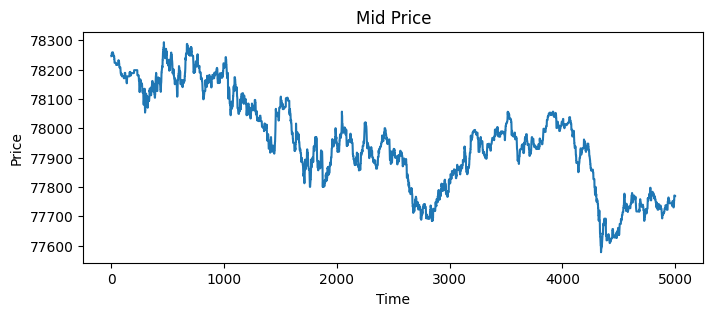

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(df["mid_price"])
plt.title("Mid Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

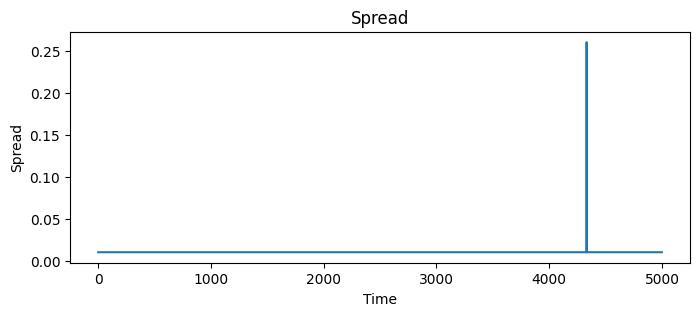

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(df["spread"])
plt.title("Spread")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.show()

### • Is the spread constant? , Is the market liquid?


In [6]:
df["spread"].describe()

count    5000.000000
mean        0.010050
std         0.003536
min         0.010000
25%         0.010000
50%         0.010000
75%         0.010000
max         0.260000
Name: spread, dtype: float64

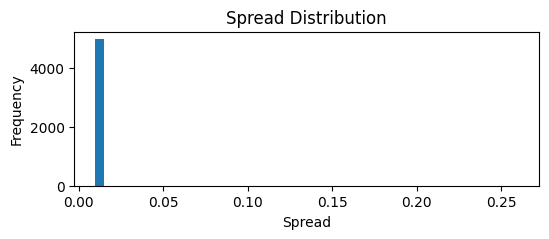

In [7]:
plt.figure(figsize=(6, 2))
plt.hist(df["spread"], bins=50)
plt.title("Spread Distribution")
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.show()

The spread is not constant. It fluctuates over time due to changes in supply and demand. However, for highly liquid assets such as BTCUSDT, the spread remains very small and relatively stable.


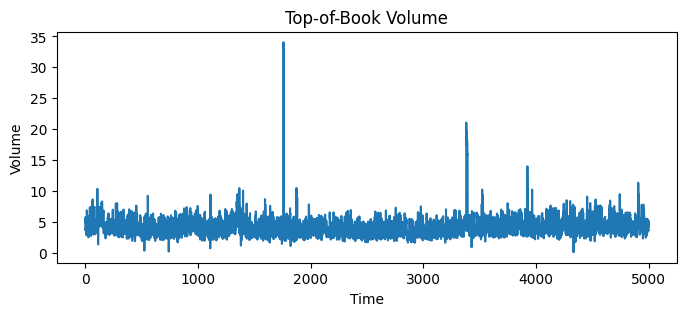

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(df["volume"])
plt.title("Top-of-Book Volume")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.show()

In [9]:
# is the market liquid?
print("Mean of spread : ", df["spread"].mean())
print("Mean of volume : ", df["volume"].mean())

Mean of spread :  0.010049999999688572
Mean of volume :  4.135543802


The market appears highly liquid. The bid-ask spread is consistently small, and the available volume at the top of the book is significant. Additionally, the mid-price evolves smoothly, indicating continuous trading activity and efficient price discovery.


### • Does imbalance predict price movements?


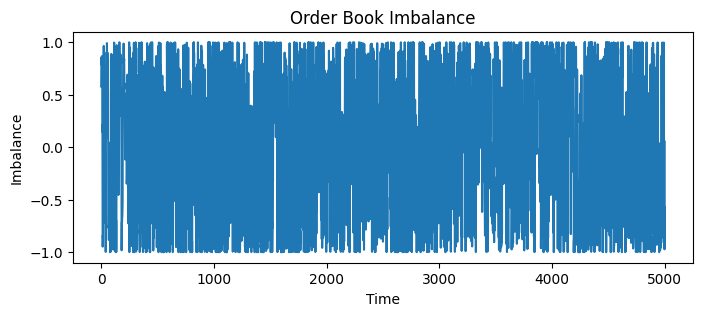

In [10]:
df["imbalance"] = (df["best_bid_qty"] - df["best_ask_qty"]) / df["volume"]
plt.figure(figsize=(8, 3))
plt.plot(df["imbalance"])
plt.title("Order Book Imbalance")
plt.xlabel("Time")
plt.ylabel("Imbalance")
plt.show()

In [11]:
df_imb = df.copy()

df_imb["future_move_10"] = df["mid_price"].shift(-10) - df["mid_price"]

# Remove zero moves
df_imb = df_imb[df_imb["future_move_10"] != 0]
pred_sign = np.sign(df_imb["imbalance"].shift(1))

real_sign = np.sign(df_imb["future_move_10"])
print("Predicted signs:", pred_sign.value_counts())
print("Actual signs:", real_sign.value_counts(), "\n")

Predicted signs: imbalance
-1.0    2582
 1.0    2290
Name: count, dtype: int64
Actual signs: future_move_10
-1.0    2451
 1.0    2412
Name: count, dtype: int64 



Why zeros happen (important insight)?

This is actually very normal:

order book updates happen very fast
mid-price often stays constant
most events are liquidity changes, not price changes

👉 This is exactly microstructure noise


In [12]:
corr = df_imb["imbalance"].corr(df_imb["future_move_10"])
print("Correlation:", corr, "\n")

accuracy = (pred_sign == real_sign).mean()
print("Directional accuracy:", accuracy, "\n")

df_imb["bucket"] = pd.qcut(df_imb["imbalance"], q=5, duplicates="drop")
print(df_imb.groupby("bucket")["future_move_10"].mean())

Correlation: 0.20964588026423858 

Directional accuracy: 0.5524317668787194 

bucket
(-1.001, -0.756]   -7.410766
(-0.756, -0.286]   -6.057830
(-0.286, 0.132]    -1.297372
(0.132, 0.688]      2.364076
(0.688, 1.0]        7.357924
Name: future_move_10, dtype: float64


- We observe that extreme order book imbalance levels are associated with future price movements.
- In particular, strong positive imbalance leads to positive returns, while negative imbalance tends to precede negative returns.
- However, the relationship is noisy for intermediate values, and the predictive power remains moderate.


### A first simple trading Strategy


strategy:

- Trading decisions are based on the conditional expectation of future returns given the imbalance.
- Positions are only taken when imbalance exceeds a threshold, reflecting strong buying or selling pressure.
- This avoids noise-dominated regions where the signal is weak.


- **Option 1 (Approximation)**

```python
pnl_net = pnl - spread / 2 * trade
```

- **Option 2 (Best / Realistic)**

```python
# Long
pnl = future_bid - current_ask

# Short
pnl = current_bid - future_ask
```

👉 The spread is automatically included in this formulation.


### Option 1


In [13]:
df_real_strategy = df.copy()

df_real_strategy["future_bid"] = df_real_strategy["best_bid_price"].shift(-h)
df_real_strategy["future_ask"] = df_real_strategy["best_ask_price"].shift(-h)

df_real_strategy = df_real_strategy.dropna(subset=["future_bid", "future_ask"])

df_real_strategy["position"] = 0
df_real_strategy.loc[df_real_strategy["imbalance"] > threshold, "position"] = 1
df_real_strategy.loc[df_real_strategy["imbalance"] < -threshold, "position"] = -1

df_real_strategy["real_pnl_per_btc"] = 0.0

# Long: buy now at ask, sell later at bid
long_mask = df_real_strategy["position"] == 1
df_real_strategy.loc[long_mask, "real_pnl_per_btc"] = (
    df_real_strategy.loc[long_mask, "future_bid"]
    - df_real_strategy.loc[long_mask, "best_ask_price"]
)

# Short: sell now at bid, buy back later at ask
short_mask = df_real_strategy["position"] == -1
df_real_strategy.loc[short_mask, "real_pnl_per_btc"] = (
    df_real_strategy.loc[short_mask, "best_bid_price"]
    - df_real_strategy.loc[short_mask, "future_ask"]
)

# Scale by traded quantity
df_real_strategy["real_pnl"] = qty * df_real_strategy["real_pnl_per_btc"]

df_real_strategy["cum_real_pnl"] = df_real_strategy["real_pnl"].cumsum()

In [14]:
mean_pnl = df_real_strategy["real_pnl"].mean()
print("Mean PnL per trade:", mean_pnl)
sharpe_ratio = df_real_strategy["real_pnl"].mean() / df_real_strategy["real_pnl"].std()
print("Sharpe Ratio:", sharpe_ratio)
hit_rate = (df_real_strategy["real_pnl"] > 0).mean()
print("Hit Rate:", hit_rate)

Mean PnL per trade: 0.002378979959919939
Sharpe Ratio: 0.16395276830502564
Hit Rate: 0.1971943887775551


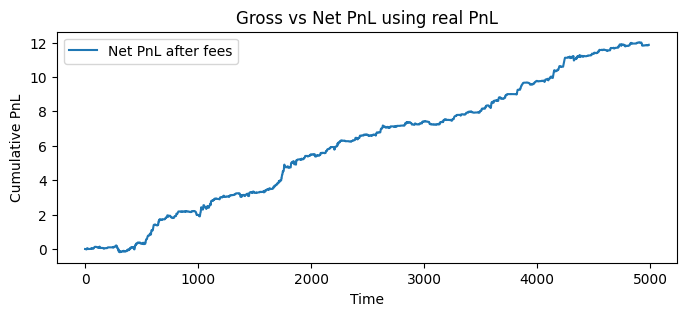

In [15]:
plt.figure(figsize=(8, 3))

plt.plot(df_real_strategy["cum_real_pnl"], label="Net PnL after fees")
plt.title("Gross vs Net PnL using real PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

##### Deducing fees

- ! we have already taken into account here transaction costs


In [16]:
df_real_strategy["entry_fee"] = 0.0
df_real_strategy["exit_fee"] = 0.0

# Long: buy at ask, sell at future bid
long_mask = df_real_strategy["position"] == 1
df_real_strategy.loc[long_mask, "entry_fee"] = (
    qty * fee_rate * df_real_strategy.loc[long_mask, "best_ask_price"]
)
df_real_strategy.loc[long_mask, "exit_fee"] = (
    qty * fee_rate * df_real_strategy.loc[long_mask, "future_bid"]
)

# Short: sell at bid, buy back at future ask
short_mask = df_real_strategy["position"] == -1
df_real_strategy.loc[short_mask, "entry_fee"] = (
    qty * fee_rate * df_real_strategy.loc[short_mask, "best_bid_price"]
)
df_real_strategy.loc[short_mask, "exit_fee"] = (
    qty * fee_rate * df_real_strategy.loc[short_mask, "future_ask"]
)


df_real_strategy["fees"] = df_real_strategy["entry_fee"] + df_real_strategy["exit_fee"]


df_real_strategy["real_pnl_net"] = (
    df_real_strategy["real_pnl"] - df_real_strategy["fees"]
)

df_real_strategy["cum_real_pnl_net"] = df_real_strategy["real_pnl_net"].cumsum()

In [17]:
mean_pnl = df_real_strategy["real_pnl_net"].mean()
print("Mean PnL per trade:", mean_pnl)
sharpe_ratio = (
    df_real_strategy["real_pnl_net"].mean() / df_real_strategy["real_pnl_net"].std()
)
print("Sharpe Ratio:", sharpe_ratio)
hit_rate = (df_real_strategy["real_pnl_net"] > 0).mean()
print("Hit Rate:", hit_rate)

Mean PnL per trade: -0.04655108417034058
Sharpe Ratio: -0.662511626853894
Hit Rate: 0.0


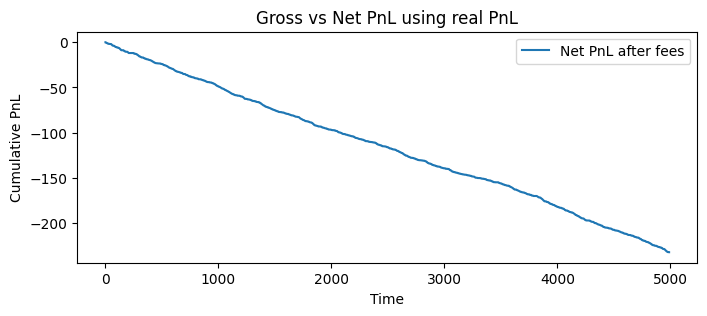

In [18]:
plt.figure(figsize=(8, 3))

plt.plot(df_real_strategy["cum_real_pnl_net"], label="Net PnL after fees")
plt.title("Gross vs Net PnL using real PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

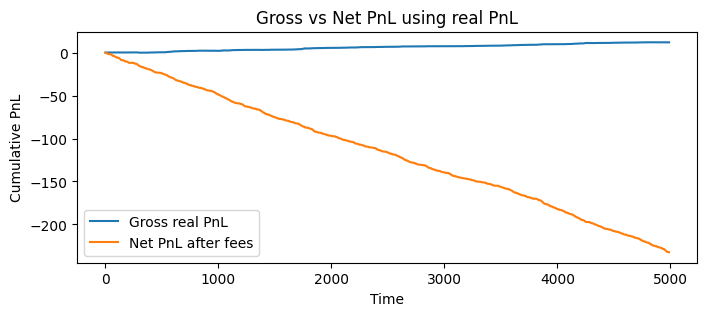

In [19]:
plt.figure(figsize=(8, 3))
plt.plot(df_real_strategy["cum_real_pnl"], label="Gross real PnL")
plt.plot(df_real_strategy["cum_real_pnl_net"], label="Net PnL after fees")
plt.title("Gross vs Net PnL using real PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

### Option 2


In [20]:
df_mid_strategy = df.copy()

df_mid_strategy["position"] = 0
df_mid_strategy.loc[df_mid_strategy["imbalance"] > threshold, "position"] = 1
df_mid_strategy.loc[df_mid_strategy["imbalance"] < -threshold, "position"] = -1

df_mid_strategy["return"] = (
    df_mid_strategy["mid_price"].shift(-h) - df_mid_strategy["mid_price"]
)

df_mid_strategy = df_mid_strategy.dropna(subset=["return"])

# Mid-price mark-to-market PnL.
# This ignores execution costs, bid-ask spread, fees, and slippage.
df_mid_strategy["pnl_mid"] = (
    qty * df_mid_strategy["position"] * df_mid_strategy["return"]
)

df_mid_strategy["cum_pnl_mid"] = df_mid_strategy["pnl_mid"].cumsum()

In [21]:
mean_pnl = df_mid_strategy["pnl_mid"].mean()
print("Mean PnL per trade:", mean_pnl)
sharpe_ratio = df_mid_strategy["pnl_mid"].mean() / df_mid_strategy["pnl_mid"].std()
print("Sharpe Ratio:", sharpe_ratio)
hit_rate = (df_mid_strategy["pnl_mid"] > 0).mean()
print("Hit Rate:", hit_rate)

Mean PnL per trade: 0.002382143286573211
Sharpe Ratio: 0.16415745708894622
Hit Rate: 0.1997995991983968


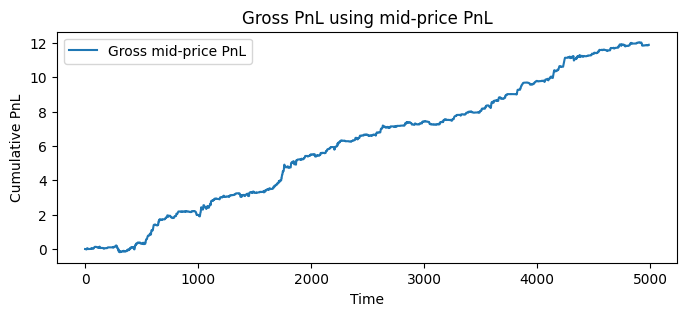

In [22]:
plt.figure(figsize=(8, 3))
plt.plot(df_mid_strategy["cum_pnl_mid"], label="Gross mid-price PnL")

plt.title("Gross PnL using mid-price PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

#### Removing trading fees + transaction costs


In [23]:
# Position size in BTC
df_mid_strategy["trade_units"] = (
    df_mid_strategy["position"].diff().abs().fillna(df_mid_strategy["position"].abs())
)

df_mid_strategy["turnover"] = qty * df_mid_strategy["trade_units"]

# Gross mid-price PnL
df_mid_strategy["pnl_mid"] = (
    qty * df_mid_strategy["position"] * df_mid_strategy["return"]
)

# Spread transaction cost
df_mid_strategy["spread_cost"] = (
    df_mid_strategy["spread"] / 2 * df_mid_strategy["turnover"]
)

# Trading fees
df_mid_strategy["fee_cost"] = (
    fee_rate * df_mid_strategy["mid_price"] * df_mid_strategy["turnover"]
)

# PnL after spread only
df_mid_strategy["pnl_mid_after_spread"] = (
    df_mid_strategy["pnl_mid"] - df_mid_strategy["spread_cost"]
)

# PnL after spread + fees
df_mid_strategy["pnl_mid_net"] = (
    df_mid_strategy["pnl_mid"]
    - df_mid_strategy["spread_cost"]
    - df_mid_strategy["fee_cost"]
)

df_mid_strategy["cum_pnl_mid"] = df_mid_strategy["pnl_mid"].cumsum()
df_mid_strategy["cum_pnl_mid_after_spread"] = df_mid_strategy[
    "pnl_mid_after_spread"
].cumsum()
df_mid_strategy["cum_pnl_mid_net"] = df_mid_strategy["pnl_mid_net"].cumsum()

In [24]:
df_mid_strategy["spread_cost"].describe()

count    4990.000000
mean        0.000002
std         0.000003
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000005
max         0.000010
Name: spread_cost, dtype: float64

In [25]:
mean_pnl = df_mid_strategy["pnl_mid_net"].mean()
print("Mean PnL per timestamp:", mean_pnl)

sharpe_ratio = (
    df_mid_strategy["pnl_mid_net"].mean() / df_mid_strategy["pnl_mid_net"].std()
)
print("Sharpe Ratio:", sharpe_ratio)

# Only timestamps where a trade actually occurs
trade_mask = df_mid_strategy["trade_units"] > 0

hit_rate = (df_mid_strategy.loc[trade_mask, "pnl_mid_net"] > 0).mean()

print("Hit Rate:", hit_rate)

Mean PnL per timestamp: -0.026049564901803473
Sharpe Ratio: -0.630134810641278
Hit Rate: 0.002285714285714286


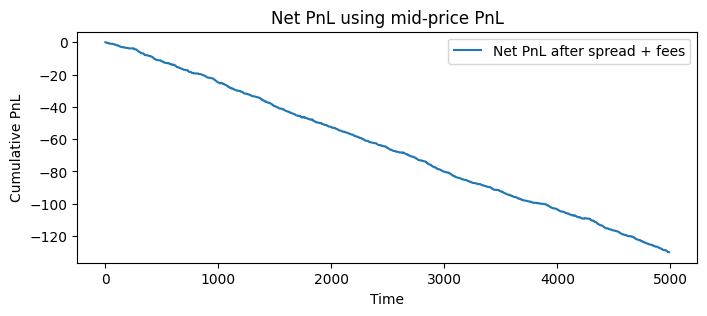

In [26]:
plt.figure(figsize=(8, 3))

plt.plot(df_mid_strategy["cum_pnl_mid_net"], label="Net PnL after spread + fees")
plt.title("Net PnL using mid-price PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

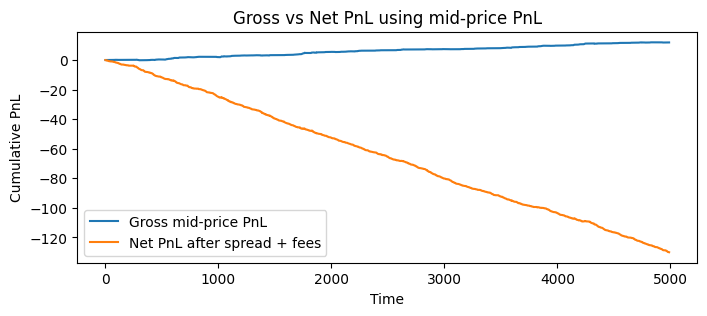

In [27]:
plt.figure(figsize=(8, 3))
plt.plot(df_mid_strategy["cum_pnl_mid"], label="Gross mid-price PnL")
plt.plot(df_mid_strategy["cum_pnl_mid_net"], label="Net PnL after spread + fees")
plt.title("Gross vs Net PnL using mid-price PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

### Comparison between option 1 (real pnl) and option 2 (mid pnl)


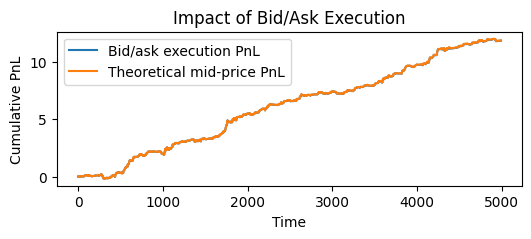

In [28]:
plt.figure(figsize=(6, 2))

plt.plot(df_real_strategy["cum_real_pnl"], label="Bid/ask execution PnL")

plt.plot(df_mid_strategy["cum_pnl_mid"], label="Theoretical mid-price PnL")

plt.title("Impact of Bid/Ask Execution")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")

plt.legend()
plt.show()

### Interpretation of the Results

The cumulative PnL obtained using realistic bid/ask execution is very close to the theoretical mid-price PnL.

This suggests that, on the BTCUSDT market, the bid-ask spread has a relatively limited impact on the gross profitability of the strategy. The market is therefore highly liquid, with tight spreads and efficient execution conditions.

The small gap between the two curves indicates that the imbalance signal remains predictive even after accounting for spread crossing through realistic bid/ask execution.

This behavior is common for highly liquid crypto assets traded on major exchanges such as Binance, where transaction costs coming from the spread are relatively small compared to the overall signal magnitude.


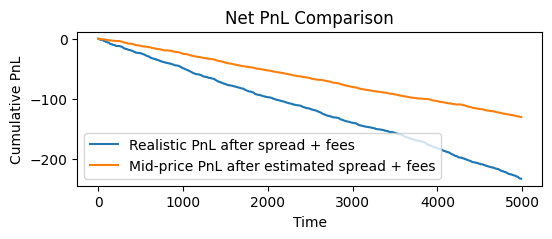

In [29]:
plt.figure(figsize=(6, 2))

plt.plot(
    df_real_strategy["cum_real_pnl_net"], label="Realistic PnL after spread + fees"
)

plt.plot(
    df_mid_strategy["cum_pnl_mid_net"],
    label="Mid-price PnL after estimated spread + fees",
)

plt.title("Net PnL Comparison")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.show()

In [30]:
print("real_pnl fee cost:", df_real_strategy["fees"].describe(), "\n")
print("Mid-price fee cost:", df_mid_strategy["fee_cost"].describe())

real_pnl fee cost: count    4990.000000
mean        0.048930
std         0.072359
min         0.000000
25%         0.000000
50%         0.000000
75%         0.155582
max         0.156537
Name: fees, dtype: float64 

Mid-price fee cost: count    4990.000000
mean        0.028430
std         0.039730
min         0.000000
25%         0.000000
50%         0.000000
75%         0.077875
max         0.156496
Name: fee_cost, dtype: float64


### Interpretation Without Trading Fees

- The realistic bid/ask execution framework generates larger cumulative trading fees than the mid-price approximation.
- This is expected since fees are applied to actual executed bid and ask prices rather than to an idealized mid-price estimate.
- The result highlights that simplified mid-price models tend to underestimate real execution costs.
- => execution modeling matters


## 📌 Question 5

We study short-term volatility:

$$ \sigma*t^2 = \mathbb{E}\left[\left(S*{t+\Delta} - S_t\right)^2\right] $$

👉 **Question:**

- Is volatility stationary?


In [31]:
df_vol = df.copy()


df_vol["future_move"] = df_vol["mid_price"].shift(-h) - df_vol["mid_price"]

df_vol = df_vol.dropna(subset=["future_move"])

df_vol["squared_move"] = df_vol["future_move"] ** 2

df_vol["short_term_variance"] = df_vol["squared_move"].rolling(window=window).mean()

df_vol["short_term_volatility"] = df_vol["short_term_variance"] ** 0.5

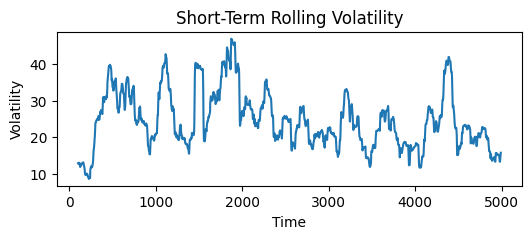

In [32]:
plt.figure(figsize=(6, 2))
plt.plot(df_vol["short_term_volatility"])
plt.title("Short-Term Rolling Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

In [33]:
df_vol["short_term_volatility"].describe()

count    4891.000000
mean       24.648804
std         7.716827
min         8.733687
25%        19.299507
50%        23.304578
75%        28.958479
max        46.801572
Name: short_term_volatility, dtype: float64

In [34]:
vol_series = df_vol["short_term_volatility"].dropna()

adf_result = adfuller(vol_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.060284463327415
p-value: 0.0011257428744996902


An Augmented Dickey–Fuller test was performed on the short-term volatility series to assess stationarity. Although the test may reject the presence of a unit root, the rolling statistics suggest the existence of volatility clustering and time-varying volatility regimes, which are common features of financial time series.


In [35]:
df_vol["block"] = pd.qcut(df_vol.index, q=5, labels=False)

df_vol.groupby("block")["short_term_volatility"].mean()

block
0    24.677273
1    30.982178
2    24.059411
3    21.235801
4    22.292180
Name: short_term_volatility, dtype: float64

The average short-term volatility varies across time blocks, suggesting that volatility is not perfectly stationary over the sample. Periods of elevated and reduced volatility can be observed, which is consistent with volatility clustering commonly observed in high-frequency financial data.


### Part III – Market Making Strategy


- Random execution : trading randomly instead of using your signal
- “Inventory evolution” means: how your current position changes over time

- In trading / market making: inventory = quantity currently held

- The np.random.rand() function in NumPy generates an array of a specified shape filled with random values uniformly distributed between 0 and 1


### Idea : Naive strategy

We quote around the mid-price:

$$
\text{bid}_t = \text{mid}_t - \delta
$$

$$
\text{ask}_t = \text{mid}_t + \delta
$$

Then we simulate random executions:

- if the bid is executed → we buy → inventory increases
- if the ask is executed → we sell → inventory decreases


In [36]:
df_naive = df.copy()

delta = df_naive["spread"].mean() / 2
df_naive["quote_bid"] = df_naive["mid_price"] - delta
df_naive["quote_ask"] = df_naive["mid_price"] + delta

In [37]:
### Simulation of random execution
np.random.seed(42)

p_exec = 0.05  # probability of execution at each time step

df_naive["bid_exec"] = np.random.rand(len(df_naive)) < p_exec
df_naive["ask_exec"] = np.random.rand(len(df_naive)) < p_exec

In [38]:
# Inventory evolution
df_naive["trade"] = 0.0

# If bid is executed, we buy
df_naive.loc[df_naive["bid_exec"], "trade"] += qty

# If ask is executed, we sell
df_naive.loc[df_naive["ask_exec"], "trade"] -= qty

df_naive["inventory"] = df_naive["trade"].cumsum()

In [39]:
# Cash and PnL
df_naive["cash_flow"] = 0.0

# Buying at bid costs money
df_naive.loc[df_naive["bid_exec"], "cash_flow"] -= (
    qty * df_naive.loc[df_naive["bid_exec"], "quote_bid"]
)

# Selling at ask receives money
df_naive.loc[df_naive["ask_exec"], "cash_flow"] += (
    qty * df_naive.loc[df_naive["ask_exec"], "quote_ask"]
)


df_naive["cash"] = df_naive["cash_flow"].cumsum()
df_naive["cash"] = df_naive["cash_flow"].cumsum()

df_naive["pnl"] = df_naive["cash"] + df_naive["inventory"] * df_naive["mid_price"]

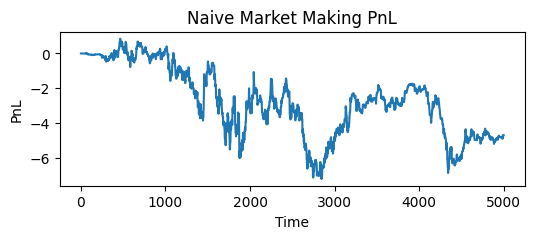

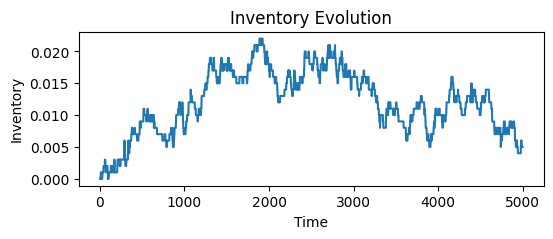

In [40]:
plt.figure(figsize=(6, 2))
plt.plot(df_naive["pnl"])
plt.title("Naive Market Making PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.show()

plt.figure(figsize=(6, 2))
plt.plot(df_naive["inventory"])
plt.title("Inventory Evolution")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.show()

In [41]:
print("Final PnL:", df_naive["pnl"].iloc[-1])
print("Average inventory:", df_naive["inventory"].mean())
print("Max absolute inventory:", df_naive["inventory"].abs().max())
print("PnL volatility:", df_naive["pnl"].diff().std())

Final PnL: -4.708482674996958
Average inventory: 0.011994000000000005
Max absolute inventory: 0.022000000000000013
PnL volatility: 0.09444748308539917


- The naive market making strategy generates PnL by quoting around the mid-price and earning the spread when executions occur.
- However, because executions are random and there is no inventory control, the inventory can drift over time.
- As a result, the PnL is not necessarily stable and may become exposed to directional price movements.


### Adding penalty\_ Inventory risk

Add an inventory penalty:

$$
\text{Penalty}_t = -\lambda q_t^2
$$

where:

- $q_t$ is the inventory at time $t$,
- $\lambda > 0$ controls the inventory risk aversion.

- What is the impact on:
  - PnL?
  - inventory distribution?


In [42]:
df_inv = df_naive.copy()

lambda_penalty = 10_000

df_inv["inventory_penalty"] = -lambda_penalty * df_inv["inventory"] ** 2

df_inv["pnl_with_penalty"] = df_inv["pnl"] + df_inv["inventory_penalty"]

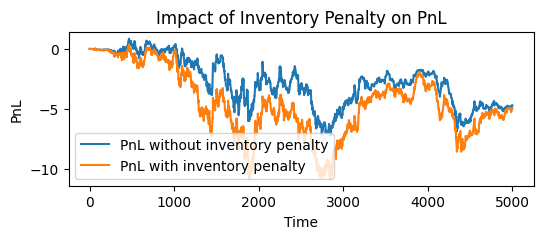

In [43]:
plt.figure(figsize=(6, 2))
plt.plot(df_inv["pnl"], label="PnL without inventory penalty")
plt.plot(df_inv["pnl_with_penalty"], label="PnL with inventory penalty")
plt.title("Impact of Inventory Penalty on PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.legend()
plt.show()

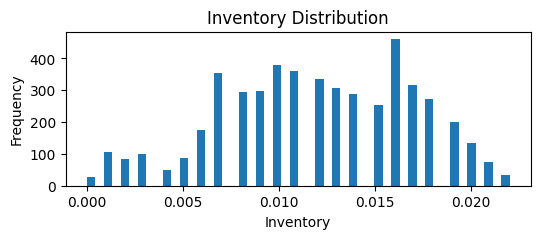

In [44]:
plt.figure(figsize=(6, 2))
plt.hist(df_inv["inventory"], bins=50)
plt.title("Inventory Distribution")
plt.xlabel("Inventory")
plt.ylabel("Frequency")
plt.show()

- The inventory penalty lowers the PnL when inventory becomes large.
- The gap between penalized and unpenalized PnL reflects the cost of holding directional exposure.

- The inventory distribution shows that the strategy accumulates positive inventory, meaning buy executions dominate sell executions.
- The strategy tends to accumulate inventory over time, which creates exposure to market price movements.

Overall, the naive strategy is exposed to inventory risk and needs inventory control.


## 📌 Question 8 – Avellaneda–Stoikov Model

Implement the Avellaneda–Stoikov optimal spread formula:

$$
\delta_t^{ask}
=
\frac{\gamma \sigma^2 (T-t)}{2}
+
\frac{1}{\gamma}
\ln\left(1+\frac{\gamma}{k}\right)
$$

$$
\delta_t^{bid}
=
\frac{\gamma \sigma^2 (T-t)}{2}
+
\frac{1}{\gamma}
\ln\left(1+\frac{\gamma}{k}\right)
$$

where:

- $\gamma$ is the risk-aversion parameter,
- $\sigma$ is the short-term volatility,
- $T-t$ is the remaining time horizon,
- $k$ controls the sensitivity of execution intensity to quote distance.


### Components of the Avellaneda–Stoikov Model

The Avellaneda–Stoikov model incorporates:

- volatility adjustment,
- risk aversion,
- inventory control.

The reservation price is:

$$
r_t
=
S_t
-
q_t \gamma \sigma^2 (T-t)
$$

where:

- $S_t$ is the mid-price,
- $q_t$ is the inventory,
- $\gamma$ is the risk-aversion parameter,
- $\sigma$ is the volatility,
- $T-t$ is the remaining time horizon.

The optimal half-spread is:

$$
\delta_t
=
\frac{\gamma \sigma^2 (T-t)}{2}
+
\frac{1}{\gamma}
\ln\left(1+\frac{\gamma}{k}\right)
$$

Interpretation:

- **Volatility adjustment**:  
  Higher volatility $\sigma$ increases the spread to protect against adverse price movements.

- **Risk aversion**:  
  Larger $\gamma$ leads to wider quotes and more conservative behavior.

- **Inventory control**:  
  The reservation price depends on inventory $q_t$.  
  Positive inventory shifts quotes downward to encourage selling, while negative inventory shifts quotes upward to encourage buying.


## Complete Structure

Finally:

$$
\text{bid}_t
=
S_t
-
q_t \gamma \sigma^2 (T-t)
-
\delta_t
$$

$$
\text{ask}_t
=
S_t
-
q_t \gamma \sigma^2 (T-t)
+
\delta_t
$$

Thus:

| Term                         | Effect               |
| ---------------------------- | -------------------- |
| $S_t$                        | natural center       |
| $-q_t \gamma \sigma^2 (T-t)$ | inventory adjustment |
| $\delta_t$                   | spread width         |

- https://hummingbot.org/blog/guide-to-the-avellaneda--stoikov-strategy/#reservation-price-explained

we will compare the Avellaneda–Stoikov strategy with the naive quoting strategy.


In [45]:
df_as = df.copy()


T = len(df_as)

df_as["price_returns"] = df_as["mid_price"].shift(-h) - df_as["mid_price"]
sigma = df_as["price_returns"].std()

T = len(df_as)
df_as["time_to_maturity"] = (T - df_as["timestamp"].index) / T

df_as["inventory"] = df_inv["inventory"].copy()

df_as["Reservation_price"] = df_as["mid_price"] - gamma * df_as["inventory"] * df_as[
    "time_to_maturity"
] * (sigma**2)

In [46]:
# Optimal half-spread
df_as["delta_as"] = (gamma * sigma**2 * df_as["time_to_maturity"]) / 2 + (
    1 / gamma
) * np.log(1 + gamma / k)

# Avellaneda-Stoikov quotes
df_as["as_bid"] = df_as["Reservation_price"] - df_as["delta_as"]
df_as["as_ask"] = df_as["Reservation_price"] + df_as["delta_as"]

In [47]:
## Random execusion
np.random.seed(42)

p_exec = 0.05

df_as["bid_exec"] = np.random.rand(len(df_as)) < p_exec
df_as["ask_exec"] = np.random.rand(len(df_as)) < p_exec

In [48]:
df_as["trade"] = 0.0

df_as.loc[df_as["bid_exec"], "trade"] += qty
df_as.loc[df_as["ask_exec"], "trade"] -= qty

df_as["inventory"] = df_as["trade"].cumsum()

df_as["cash_flow"] = 0.0

# Buy at Avellaneda-Stoikov bid
df_as.loc[df_as["bid_exec"], "cash_flow"] -= (
    qty * df_as.loc[df_as["bid_exec"], "as_bid"]
)

# Sell at Avellaneda-Stoikov ask
df_as.loc[df_as["ask_exec"], "cash_flow"] += (
    qty * df_as.loc[df_as["ask_exec"], "as_ask"]
)

df_as["cash"] = df_as["cash_flow"].cumsum()

df_as["pnl"] = df_as["cash"] + df_as["inventory"] * df_as["mid_price"]

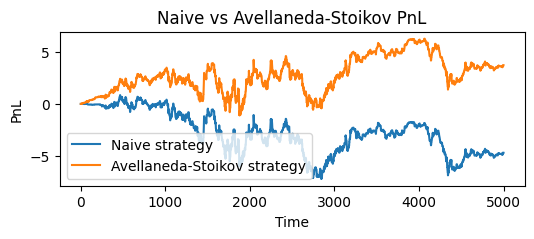

In [49]:
plt.figure(figsize=(6, 2))

plt.plot(df_naive["pnl"], label="Naive strategy")
plt.plot(df_as["pnl"], label="Avellaneda-Stoikov strategy")

plt.title("Naive vs Avellaneda-Stoikov PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.legend()
plt.show()

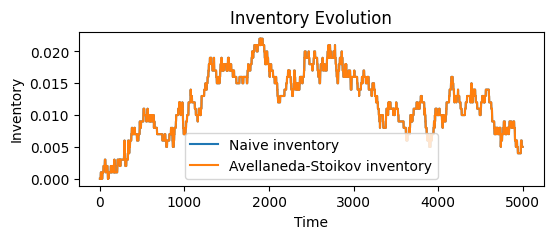

In [50]:
plt.figure(figsize=(6, 2))

plt.plot(df_naive["inventory"], label="Naive inventory")
plt.plot(df_as["inventory"], label="Avellaneda-Stoikov inventory")

plt.title("Inventory Evolution")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.show()

In [51]:
print("Naive final PnL:", df_naive["pnl"].iloc[-1])
print("AS final PnL:", df_as["pnl"].iloc[-1])

print("Naive max inventory:", df_naive["inventory"].abs().max())
print("AS max inventory:", df_as["inventory"].abs().max())

print("Naive inventory std:", df_naive["inventory"].std())
print("AS inventory std:", df_as["inventory"].std())

Naive final PnL: -4.708482674996958
AS final PnL: 3.731389888779745
Naive max inventory: 0.022000000000000013
AS max inventory: 0.022000000000000013
Naive inventory std: 0.004944699587518153
AS inventory std: 0.004944699587518153


- Even with the same inventory process and random executions, the Avellaneda–Stoikov strategy generates a different PnL because the quoted bid and ask prices are adjusted using volatility and risk aversion.

- The wider and dynamically adjusted spreads lead to improved spread capture compared with the naive constant-spread strategy.

- However, inventory control is not fully reflected in this simplified simulation since executions remain independent of the quotes.


### Dynamic Adjustment

Adapt quotes using:

- inventory,
- microstructure signals.

Example:

$$
\text{Skew}_t \propto q_t + \text{Imbalance}_t
$$

where:

- $q_t$ is the inventory,
- $\text{Imbalance}_t$ is the order book imbalance.

👉 **Question:**

- Does this improve the Sharpe ratio?


In [52]:
df_dyn = df.copy()

delta = df_dyn["spread"].mean() / 2

df_dyn["inventory"] = df_naive["inventory"]

df_dyn["skew"] = alpha_q * df_dyn["inventory"] + alpha_imb * df_dyn["imbalance"]

df_dyn["dyn_bid"] = df_dyn["mid_price"] - delta - df_dyn["skew"]
df_dyn["dyn_ask"] = df_dyn["mid_price"] + delta - df_dyn["skew"]

In [53]:
# Random execution
df_dyn["bid_exec"] = df_naive["bid_exec"]
df_dyn["ask_exec"] = df_naive["ask_exec"]

In [54]:
df_dyn["trade"] = 0.0

df_dyn.loc[df_dyn["bid_exec"], "trade"] += qty
df_dyn.loc[df_dyn["ask_exec"], "trade"] -= qty

df_dyn["inventory"] = df_dyn["trade"].cumsum()

df_dyn["cash_flow"] = 0.0

df_dyn.loc[df_dyn["bid_exec"], "cash_flow"] -= (
    qty * df_dyn.loc[df_dyn["bid_exec"], "dyn_bid"]
)

df_dyn.loc[df_dyn["ask_exec"], "cash_flow"] += (
    qty * df_dyn.loc[df_dyn["ask_exec"], "dyn_ask"]
)

df_dyn["cash"] = df_dyn["cash_flow"].cumsum()

df_dyn["pnl"] = df_dyn["cash"] + df_dyn["inventory"] * df_dyn["mid_price"]

In [55]:
df_naive["pnl_change"] = df_naive["pnl"].diff()
df_dyn["pnl_change"] = df_dyn["pnl"].diff()
df_as["pnl_change"] = df_as["pnl"].diff()

naive_sharpe = df_naive["pnl_change"].mean() / df_naive["pnl_change"].std()
dyn_sharpe = df_dyn["pnl_change"].mean() / df_dyn["pnl_change"].std()
as_sharpe = df_as["pnl_change"].mean() / df_as["pnl_change"].std()

print(f"Naive Sharpe: {naive_sharpe:.4f}")
print(f"Avellaneda–Stoikov Model Sharpe: {as_sharpe:.4f}")
print(f"Dynamic Sharpe: {dyn_sharpe:.4f}")

Naive Sharpe: -0.0100
Avellaneda–Stoikov Model Sharpe: 0.0079
Dynamic Sharpe: -0.0099


The Avellaneda–Stoikov strategy achieves the best Sharpe ratio among the tested strategies. This suggests that volatility-aware and risk-adjusted quoting improves the stability of the PnL compared with the naive strategy.

The dynamic adjustment strategy slightly improves the Sharpe ratio relative to the naive strategy, but the improvement remains limited in this simplified simulation.

Overall, incorporating risk aversion and quote adjustment mechanisms appears beneficial for market-making performance.


# — PnL Decomposition —

Yes — you can calculate the PnL decomposition from your backtest/model if you saved:

- the executed trades,
- the quoted bid/ask prices,
- the mid-price through time,
- the execution price,
- the inventory through time.

The decomposition is not unique, but there is a clean practical version that works well for an interview or project report.

---

## Required variables

Let:

$m_t = \text{mid-price at time } t$

$p_i = \text{execution price of trade } i$

$q_i = \text{signed trade size of trade } i$

$Q_t = \text{inventory at time } t$

We use the convention:

$q_i > 0 \quad \text{if we buy}$

$q_i < 0 \quad \text{if we sell}$

---

## Total mark-to-market PnL

The total PnL at time $T$ is:

$$
\text{PnL}_T = \text{cash}_T + Q_T m_T
$$

where:

$$
\text{cash}_T = - \sum_i q_i p_i
$$

Therefore:

$$
\text{PnL}_T = - \sum_i q_i p_i + Q_T m_T
$$

---

# 1. Spread capture

For each trade, the spread capture is:

$$
\text{Spread Capture}_i = q_i(m_i - p_i)
$$

where $m_i$ is the mid-price at the execution time.

If we buy at the bid:

$$
p_i < m_i, \qquad q_i > 0
$$

so:

$$
q_i(m_i - p_i) > 0
$$

If we sell at the ask:

$$
p_i > m_i, \qquad q_i < 0
$$

so again:

$$
q_i(m_i - p_i) > 0
$$

Therefore, the total spread capture is:

$$
\text{Spread Capture}
=
\sum_i q_i(m_i - p_i)
$$

This is the profit earned from executing passively inside the bid-ask spread.

---

# 2. Adverse selection

Choose a short horizon $\Delta$, for example:

- 1 second,
- 5 seconds,
- 10 seconds,
- 1 minute.

The adverse selection component is:

$$
\text{Adverse Selection}_\Delta
=
\sum_i q_i(m_{i+\Delta} - m_i)
$$

where $m_{i+\Delta}$ is the mid-price after the trade.

Interpretation:

If we buy and the mid-price goes down after the trade, then:

$$
q_i > 0,
\qquad
m_{i+\Delta} - m_i < 0
$$

so the contribution is negative.

If we sell and the mid-price goes up after the trade, then:

$$
q_i < 0,
\qquad
m_{i+\Delta} - m_i > 0
$$

so the contribution is also negative.

Therefore, a negative adverse selection term means that the strategy is being picked off by informed or aggressive flow.

We can write:

$$
\text{Trade Markout PnL}_\Delta
=
\text{Spread Capture}
+
\text{Adverse Selection}_\Delta
$$

---

# 3. Inventory cost

The inventory component measures the PnL generated by holding inventory while the mid-price moves.

A practical formula is:

$$
\text{Inventory PnL}
=
\sum_t Q_{t^-}(m_t - m_{t^-})
$$

where $Q_{t^-}$ is the inventory just before the price move.

If we want to report it as a cost, we define:

$$
\text{Inventory Cost}
=
-
\sum_t Q_{t^-}(m_t - m_{t^-})
$$

So:

$$
\text{Inventory Cost}
=
-\text{Inventory PnL}
$$

If inventory PnL is negative, inventory hurt the strategy.

If inventory PnL is positive, inventory helped the strategy.

---

# Final interpretation

The main driver of profit or loss is identified by comparing the three components:

$$
\text{Spread Capture},
\qquad
\text{Adverse Selection},
\qquad
\text{Inventory PnL}.
$$

If spread capture is the largest positive component, the strategy makes money mainly by earning the bid-ask spread.

If adverse selection is strongly negative, the strategy loses money because it is trading just before unfavorable price moves.

If inventory cost dominates, the strategy loses money mainly because it carries too much directional exposure.

A clean interview answer is:

> In my model, I decompose the PnL into spread capture, adverse selection, and inventory PnL.  
> Spread capture measures how much I earn from buying at the bid and selling at the ask.  
> Adverse selection measures whether the mid-price moves against me after my trades.  
> Inventory PnL measures the mark-to-market impact of holding inventory.  
> The main driver of profit or loss is the component with the largest contribution in absolute value.


In [56]:
# Spread capture for Avellaneda-Stoikov

Spread_component = (
    df_as.loc[df_as["bid_exec"], "trade"]
    * (
        df_as.loc[df_as["bid_exec"], "mid_price"]
        - df_as.loc[df_as["bid_exec"], "as_bid"]
    )
).sum() + (
    df_as.loc[df_as["ask_exec"], "trade"]
    * (
        df_as.loc[df_as["ask_exec"], "mid_price"]
        - df_as.loc[df_as["ask_exec"], "as_ask"]
    )
).sum()

Spread_component

np.float64(8.296218708200382)

In [57]:
df_as["future_mid"] = df_as["mid_price"].shift(-h)

adverse_selection_pnl = (
    df_as["trade"] * (df_as["future_mid"] - df_as["mid_price"])
).sum()

adverse_selection_cost = -adverse_selection_pnl

print(adverse_selection_pnl)
print(adverse_selection_cost)

-0.31421000000015215
0.31421000000015215


In [58]:
df_as["next_mid"] = df_as["mid_price"].shift(-1)

inventory_pnl_component = (
    df_as["inventory"] * (df_as["next_mid"] - df_as["mid_price"])
).sum()

inventory_cost_component = -inventory_pnl_component

print(inventory_pnl_component)
print(inventory_cost_component)

-4.710960000000023
4.710960000000023


In [59]:
print("Total PnL:", df_as["pnl"].iloc[-1])
print("Spread capture component:", Spread_component)
print("Adverse selection cost:", adverse_selection_cost)
print("Inventory cost component:", inventory_cost_component)

Total PnL: 3.731389888779745
Spread capture component: 8.296218708200382
Adverse selection cost: 0.31421000000015215
Inventory cost component: 4.710960000000023


### Profitable strategy:

let's focus only on the Avellaneda-Stoikov strategy and try to find a profitable strategy

- **What does latency mean in trading?**
- Trade latency refers to the time interval between an order being placed and its execution.
- Lower latency is desirable as it means that a trader has a higher possibility of securing the price displayed before the market moves.
- Traders can reduce the latency of their trading by subscribing to a VPS service.


# Theory — Avellaneda–Stoikov Market-Making Strategy

We focus on the Avellaneda–Stoikov market-making strategy.

The goal of a market maker is to continuously quote a bid price and an ask price around the mid-price:

$$
m_t = \frac{P_t^{bid} + P_t^{ask}}{2}.
$$

The market maker earns money by buying at the bid and selling at the ask. However, the strategy faces two main risks:

1. **Inventory risk**: holding too much long or short inventory.
2. **Execution risk / adverse selection**: being executed just before the price moves against us.

The Avellaneda–Stoikov framework adjusts the quoted bid and ask prices dynamically using the current inventory and the short-term volatility.

---

## 1. Reservation price

The first key idea is the **reservation price**.

Instead of quoting around the mid-price directly, the market maker quotes around an adjusted price:

$$
r_t = m_t - \gamma Q_t \sigma_t^2 (T-t).
$$

where:

- $m_t$ is the mid-price,
- $Q_t$ is the current inventory,
- $\sigma_t$ is the short-term volatility,
- $\gamma$ is the risk-aversion parameter,
- $T-t$ is the remaining trading horizon.

The reservation price shifts the quotes depending on inventory.

If the market maker is long, meaning:

$$
Q_t > 0,
$$

then:

$$
r_t < m_t.
$$

So the strategy shifts both quotes downward. This makes the ask quote more attractive and encourages selling inventory.

If the market maker is short, meaning:

$$
Q_t < 0,
$$

then:

$$
r_t > m_t.
$$

So the strategy shifts both quotes upward. This makes the bid quote more attractive and encourages buying back inventory.

Therefore, the reservation price controls inventory risk.

---

## 2. Optimal half-spread

The second key idea is the optimal spread.

The Avellaneda–Stoikov half-spread is:

$$
\delta_t =
\frac{1}{2}\gamma \sigma_t^2 (T-t)
+
\frac{1}{\gamma}\log\left(1+\frac{\gamma}{k}\right).
$$

Then the bid and ask quotes are:

$$
p_t^{bid} = r_t - \delta_t,
$$

$$
p_t^{ask} = r_t + \delta_t.
$$

The spread is therefore:

$$
p_t^{ask} - p_t^{bid} = 2\delta_t.
$$

The parameter $k$ controls the sensitivity of order arrivals to quote distance.

The parameter $\gamma$ controls risk aversion.

If $\gamma$ is high, the market maker is more risk-averse and usually quotes more conservatively.

If volatility $\sigma_t$ is high, the strategy increases the spread because price risk is larger.

---

## 3. Why we changed the execution model

In the first version of the model, executions were random.

That means the probability of a bid or ask execution did not depend on the quoted prices.

This is not realistic because in real markets:

- if we quote close to the mid-price, we are more likely to be executed;
- if we quote far away from the mid-price, we are less likely to be executed.

So if executions are purely random, the strategy can become profitable just by quoting wider prices, without paying the cost of lower execution probability.

To make the model more realistic, we changed the execution mechanism.

---

## 4. Distance-based execution probability

We now make the execution probability depend on the distance between the quote and the mid-price.

For the bid side:

$$
d_t^{bid} = \frac{m_t - p_t^{bid}}{\text{spread}_t}.
$$

For the ask side:

$$
d_t^{ask} = \frac{p_t^{ask} - m_t}{\text{spread}_t}.
$$

Then the execution probabilities are:

$$
\mathbb{P}(\text{bid execution at }t)
=
p_0 e^{-k_{\text{fill}} d_t^{bid}},
$$

$$
\mathbb{P}(\text{ask execution at }t)
=
p_0 e^{-k_{\text{fill}} d_t^{ask}}.
$$

where:

- $p_0$ is the base execution probability,
- $k_{\text{fill}}$ controls how fast execution probability decreases with distance.

This creates a realistic trade-off:

- wider quotes give more profit per trade,
- but wider quotes are less likely to be executed.

---

## 5. Inventory limit

We also add an inventory limit:

$$
|Q_t| \leq Q_{\max}.
$$

If inventory is already too long, we stop buying:

$$
Q_t \geq Q_{\max}
\quad \Rightarrow \quad
\mathbb{P}(\text{bid execution}) = 0.
$$

If inventory is already too short, we stop selling:

$$
Q_t \leq -Q_{\max}
\quad \Rightarrow \quad
\mathbb{P}(\text{ask execution}) = 0.
$$

This prevents the strategy from accumulating an uncontrolled position.

---

## 6. PnL computation

At each time step, we update cash and inventory.

If the bid is executed, we buy:

$$
Q_t = Q_{t-1} + q,
$$

$$
\text{cash}_t = \text{cash}_{t-1} - q p_t^{bid}.
$$

If the ask is executed, we sell:

$$
Q_t = Q_{t-1} - q,
$$

$$
\text{cash}_t = \text{cash}_{t-1} + q p_t^{ask}.
$$

The mark-to-market PnL is:

$$
\text{PnL}_t = \text{cash}_t + Q_t m_t.
$$

This means that the final PnL includes both:

- realized gains from executed trades,
- unrealized mark-to-market value of the remaining inventory.

---

## 7. Parameter search

After defining the strategy, we search over different values of:

- $\gamma$: risk aversion,
- $k$: Avellaneda–Stoikov intensity parameter,
- $k_{\text{fill}}$: execution-probability decay,
- $p_0$: base execution probability,
- $Q_{\max}$: inventory limit.

For each parameter set, we compute:

- final PnL,
- Sharpe ratio,
- maximum drawdown,
- maximum inventory,
- number of trades.

The objective is not only to maximize final PnL, but also to find a strategy with controlled inventory and reasonable drawdown.

---

## 8. Interpretation

The improved Avellaneda–Stoikov strategy is more realistic than the first version because execution probability depends on quote distance.

The strategy becomes profitable if it finds the right balance between:

1. capturing enough spread,
2. avoiding excessive inventory,
3. not quoting so wide that it receives too few executions,
4. reducing exposure when volatility is high.

In summary, the Avellaneda–Stoikov strategy dynamically adjusts bid and ask quotes using inventory and volatility. The reservation price controls inventory risk, the spread controls execution profitability, and the distance-based fill probability makes the backtest more realistic.


In [60]:
lambda_as = 0.005
kappa = 200
k_fill = 0.003
p0 = 0.20
Qmax = 0.02

In [61]:
def avellaneda_profitable_strat(
    df,
    lambda_as,
    kappa,
    k_fill,
    p0,
    Qmax,
    qty=0.001,
    vol_window=100,
    seed=42,
):
    rng = np.random.default_rng(seed)

    df_prf = df.copy().reset_index(drop=True)

    # Short-term volatility estimate
    df_prf["price_returns"] = df_prf["mid_price"].diff()
    df_prf["sigma"] = (
        df_prf["price_returns"]
        .rolling(vol_window)
        .std()
        .bfill()
        .fillna(df_prf["price_returns"].std())
    )

    # Initialize columns
    df_prf["time_to_maturity"] = np.linspace(1, 0, len(df_prf))
    df_prf["inventory"] = 0.0
    df_prf["reservation_price"] = np.nan
    df_prf["delta_as"] = np.nan
    df_prf["as_bid"] = np.nan
    df_prf["as_ask"] = np.nan
    df_prf["bid_exec"] = False
    df_prf["ask_exec"] = False
    df_prf["trade"] = 0.0
    df_prf["cash_flow"] = 0.0
    df_prf["cash"] = 0.0
    df_prf["pnl"] = 0.0
    df_prf["pnl_change"] = 0.0
    df_prf["p_bid_exec"] = 0.0
    df_prf["p_ask_exec"] = 0.0

    inventory = 0.0
    cash = 0.0
    previous_pnl = 0.0

    print("Starting profitable strategy simulation...")

    for t in tqdm(range(len(df_prf)), desc="Simulating profitable strategy"):

        mid_price = df_prf.loc[t, "mid_price"]
        spread = max(df_prf.loc[t, "spread"], 1e-8)
        time_to_maturity = df_prf.loc[t, "time_to_maturity"]
        sigma = df_prf.loc[t, "sigma"]

        # Reservation price
        reservation_price = (
            mid_price
            - lambda_as * inventory * time_to_maturity * sigma**2
        )

        # Avellaneda-Stoikov half-spread
        delta_as = (
            (lambda_as * sigma**2 * time_to_maturity) / 2
            + (1 / lambda_as) * np.log(1 + lambda_as / kappa)
        )

        # Do not quote tighter than half the observed market spread
        delta_as = max(delta_as, spread / 2)

        as_bid = reservation_price - delta_as
        as_ask = reservation_price + delta_as

        # Distance from mid-price, measured in spread units
        d_bid = max(0, (mid_price - as_bid) / spread)
        d_ask = max(0, (as_ask - mid_price) / spread)

        # Fill probabilities
        p_bid_exec = p0 * np.exp(-k_fill * d_bid)
        p_ask_exec = p0 * np.exp(-k_fill * d_ask)

        # Inventory control
        if inventory + qty > Qmax:
            p_bid_exec = 0.0

        if inventory - qty < -Qmax:
            p_ask_exec = 0.0

        p_bid_exec = np.clip(p_bid_exec, 0, 1)
        p_ask_exec = np.clip(p_ask_exec, 0, 1)

        # Simulate executions
        bid_exec = rng.random() < p_bid_exec
        ask_exec = rng.random() < p_ask_exec

        trade = qty * (int(bid_exec) - int(ask_exec))

        cash_flow = (
            - as_bid * qty * int(bid_exec)
            + as_ask * qty * int(ask_exec)
        )

        inventory += trade
        cash += cash_flow

        pnl = cash + inventory * mid_price
        pnl_change = pnl - previous_pnl
        previous_pnl = pnl

        # Save values
        df_prf.loc[t, "reservation_price"] = reservation_price
        df_prf.loc[t, "delta_as"] = delta_as
        df_prf.loc[t, "as_bid"] = as_bid
        df_prf.loc[t, "as_ask"] = as_ask
        df_prf.loc[t, "p_bid_exec"] = p_bid_exec
        df_prf.loc[t, "p_ask_exec"] = p_ask_exec
        df_prf.loc[t, "bid_exec"] = bid_exec
        df_prf.loc[t, "ask_exec"] = ask_exec
        df_prf.loc[t, "trade"] = trade
        df_prf.loc[t, "inventory"] = inventory
        df_prf.loc[t, "cash_flow"] = cash_flow
        df_prf.loc[t, "cash"] = cash
        df_prf.loc[t, "pnl"] = pnl
        df_prf.loc[t, "pnl_change"] = pnl_change

    return df_prf
df_profitable = avellaneda_profitable_strat(df, lambda_as, kappa, k_fill, p0, Qmax)
print()
print("Profitable strategy final PnL:", df_profitable["pnl"].iloc[-1])
print("Profitable strategy Sharpe:", df_profitable["pnl_change"].mean() / df_profitable["pnl_change"].std())
print("max_drawdown:", (df_profitable["pnl"].cummax() - df_profitable["pnl"]).max())
print("Final inventory:", df_profitable["inventory"].iloc[-1])
print("Max inventory:", df_profitable["inventory"].abs().max())
print('number of trades:', df_profitable['trade'].abs().sum() / qty)

    

Starting profitable strategy simulation...


Simulating profitable strategy: 100%|██████████| 5000/5000 [00:12<00:00, 390.77it/s]


Profitable strategy final PnL: 1.6442761245590418
Profitable strategy Sharpe: 0.003845002813744951
max_drawdown: 6.096983552635663
Final inventory: -0.003
Max inventory: 0.01900000000000001
number of trades: 1561.0


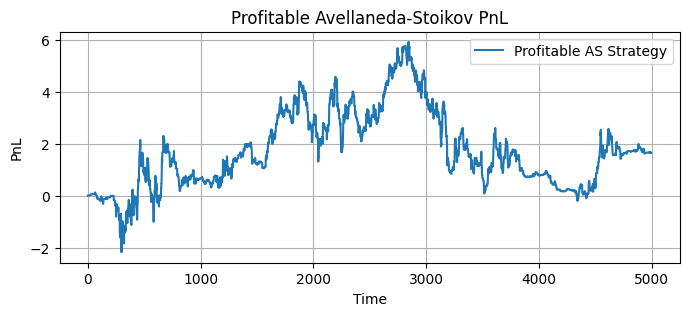

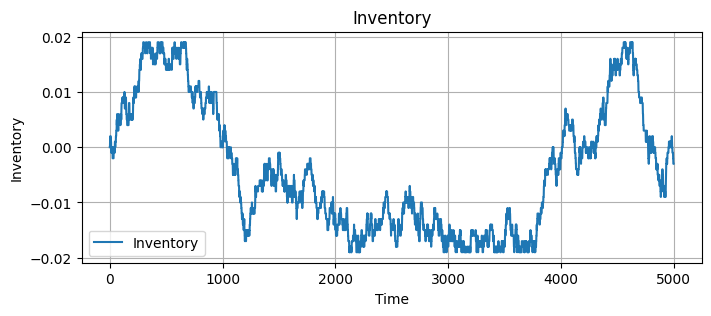

In [62]:
plt.figure(figsize=(8, 3))
plt.plot(df_profitable["pnl"], label="Profitable AS Strategy")
plt.title("Profitable Avellaneda-Stoikov PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(df_profitable["inventory"], label="Inventory")
plt.title("Inventory")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
def compute_as_metrics(df_strategy):
    pnl = df_strategy["pnl"]
    pnl_change = df_strategy["pnl_change"]

    final_pnl = pnl.iloc[-1]

    if pnl_change.std() > 0:
        sharpe = pnl_change.mean() / pnl_change.std() * np.sqrt(len(pnl_change))
    else:
        sharpe = np.nan

    drawdown = pnl.cummax() - pnl
    max_drawdown = drawdown.max()

    max_inventory = df_strategy["inventory"].abs().max()

    n_bid_exec = df_strategy["bid_exec"].sum()
    n_ask_exec = df_strategy["ask_exec"].sum()
    n_trades = n_bid_exec + n_ask_exec

    return {
        "final_pnl": final_pnl,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "max_inventory": max_inventory,
        "n_bid_exec": n_bid_exec,
        "n_ask_exec": n_ask_exec,
        "n_trades": n_trades,
    }

In [64]:
# lambda_as_values = [0.001, 0.005, 0.01, 0.02, 0.05]
# kappa_values = [50, 100, 200, 500, 1000]
# k_fill_values = [0.01, 0.03, 0.05, 0.1]
# p0_values = [0.05, 0.10, 0.20, 0.30]
# Qmax_values = [0.005, 0.01, 0.02, 0.03]

# results = []
# for lambda_as in tqdm(lambda_as_values, desc="Lambda AS"):
#     for kappa in kappa_values:
#         for k_fill in k_fill_values:
#             for p0 in p0_values:
#                 for Qmax in Qmax_values:

#                     df_test = avellaneda_profitable_strat(
#                         df,
#                         lambda_as,
#                         kappa,
#                         k_fill,
#                         p0,
#                         Qmax,
#                         qty=0.001,
#                         vol_window=100,
#                         seed=42,
#                     )

#                     metrics = compute_as_metrics(df_test)

#                     metrics["lambda_as"] = lambda_as
#                     metrics["kappa"] = kappa
#                     metrics["k_fill"] = k_fill
#                     metrics["p0"] = p0
#                     metrics["Qmax"] = Qmax

#                     results.append(metrics)

# results_df = pd.DataFrame(results)

# results_df.sort_values(by=["final_pnl", "sharpe"], ascending=False).head(10) 

In [65]:
# best = results_df.sort_values(by=["final_pnl", "sharpe"], ascending=False).iloc[0]

# best

In [66]:
# df_as_best = avellaneda_profitable_strat(
#     df,
#     lambda_as=best["lambda_as"],
#     kappa=best["kappa"],
#     k_fill=best["k_fill"],
#     p0=best["p0"],
#     Qmax=best["Qmax"],
#     qty=0.001,
#     vol_window=100,
#     seed=42,
# )

# print("Best final PnL:", df_as_best["pnl"].iloc[-1])
# print("Best Sharpe:", compute_as_metrics(df_as_best)["sharpe"])
# print("Best max drawdown:", compute_as_metrics(df_as_best)["max_drawdown"])
# print("Best max inventory:", df_as_best["inventory"].abs().max())
# print("Bid executions:", df_as_best["bid_exec"].sum())
# print("Ask executions:", df_as_best["ask_exec"].sum())

In [67]:
# plt.figure(figsize=(6, 2))
# plt.plot(df_as_best["pnl"])
# plt.title("Best Avellaneda-Stoikov PnL")
# plt.xlabel("Time")
# plt.ylabel("PnL")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(6, 2))
# plt.plot(df_as_best["inventory"])
# plt.title("Best Avellaneda-Stoikov Inventory")
# plt.xlabel("Time")
# plt.ylabel("Inventory")
# plt.grid(True)
# plt.show()

### Commenting results : 

The optimized Avellaneda–Stoikov strategy is profitable, with a final PnL of about **6.43** and a Sharpe ratio of **1.05**. The number of bid and ask executions is balanced, which suggests that the strategy is not overly biased toward one side of the market.

However, the maximum drawdown is relatively large, around **5.70**, and the inventory reaches almost the imposed limit of **0.02**. This means that although the strategy is profitable, it still carries significant inventory risk. The strategy should therefore be validated on an out-of-sample test set before concluding that the profitability is robust.



## Improvements Before Large-Scale Backtesting and Optuna Optimization

Before testing the Avellaneda–Stoikov strategy on a larger dataset and optimizing it with Optuna, we first improve the realism and robustness of the backtest.

The current version is profitable, but it still has some limitations:

- executions are simulated and not fully calibrated;
- inventory often reaches the imposed limit;
- drawdown is relatively large compared to final PnL;
- transaction fees are not fully included;
- quotes are not rounded to the market tick size;
- the imbalance signal is not yet fully exploited;
- the strategy is tested with only one random seed.

The objective of the next step is to make the strategy more realistic before doing large-scale optimization.

### Contract specifications included in the backtest

We now take into account the BTCUSD-PERP contract specifications.

The product has:

- **minimum order quantity**: $0.0001$ BTC;
- **minimum tick size**: $0.1$ USD;
- **contract size**: $1$ BTC;
- **passive trading bandwidth**: $\pm 50\%$ of MarkPrice;
- **aggressive trading bandwidth**: $\pm 5\%$ of MarkPrice.

In the backtest, this means that quoted bid and ask prices cannot be arbitrary continuous values. They must be rounded to the tick size. Bid prices are rounded down, while ask prices are rounded up.

The trading quantity must also be at least the minimum order quantity. Since the strategy uses $q = 0.001$ BTC, the order size is valid because:

\[
0.001 > 0.0001.
\]

We also enforce the passive trading bandwidth by requiring quotes to remain within $\pm 50\%$ of the MarkPrice. In the backtest, the mid-price is used as a proxy for the MarkPrice.

These constraints make the simulated quotes closer to executable market quotes.


### 1. Avoid look-ahead bias in volatility estimation

The volatility used in the Avellaneda–Stoikov formula should only use past information.

Instead of using a rolling volatility directly at time \(t\), we shift it by one step:

$$
\sigma_t = \text{RollingStd}(\Delta m_{t-1}, \Delta m_{t-2}, \dots)
$$

This ensures that the strategy does not use future information when quoting.



### 2. Add transaction fees

A strategy can look profitable before fees but become unprofitable after fees.

We therefore include fees in the cash-flow update:

$$
\text{cash}_t
=
\text{cash}_{t-1}
- q p_t^{bid}
- \text{fee}^{bid}_t
$$

for a bid execution, and:

$$
\text{cash}_t
=
\text{cash}_{t-1}
+ q p_t^{ask}
- \text{fee}^{ask}_t
$$

for an ask execution.

This makes the backtest more realistic and avoids overestimating profitability.



### 3. Round quotes to the tick size

In real markets, prices cannot take arbitrary continuous values.

For BTCUSDT, the tick size is usually small, for example:

$$
\text{tick size} = 0.01.
$$

We round bid and ask quotes as follows:

$$
p_t^{bid}
=
\left\lfloor \frac{p_t^{bid}}{\text{tick}} \right\rfloor
\text{tick}
$$

and:

$$
p_t^{ask}
=
\left\lceil \frac{p_t^{ask}}{\text{tick}} \right\rceil
\text{tick}.
$$

This prevents the strategy from using unrealistic prices.



### 4. Add an imbalance adjustment to the reservation price

Earlier, we found that order-book imbalance has some predictive power for short-term price moves.

We can use this signal in the reservation price:

$$
r_t
=
m_t
-
\gamma Q_t \sigma_t^2 (T-t)
+
\alpha_{\text{imb}} I_t \text{spread}_t.
$$

where:

- $m_t$ is the mid-price;
- $Q_t$ is the inventory;
- $sigma_t$ is the short-term volatility;
- $I_t$ is the order-book imbalance;
- $alpha_{\text{imb}}$ controls the strength of the imbalance signal.

If the imbalance is positive, there is more bid-side pressure, so the reservation price is shifted upward.

If the imbalance is negative, there is more ask-side pressure, so the reservation price is shifted downward.

This allows the strategy to quote in the direction suggested by the order book.


### 5. Widen quotes when imbalance is large

A strong imbalance can indicate directional pressure and potential adverse selection.

To reduce the risk of being picked off, we widen the spread when the imbalance is large:

$$
\delta_t^{new}
=
\delta_t
\left(
1 + \alpha_{\text{risk}} |I_t|
\right).
$$

When $|I_t|$ is large, the strategy quotes more conservatively.

This reduces execution probability during risky periods, but it can also reduce adverse selection.


### 6. Add stronger inventory control

The current strategy sometimes reaches the inventory limit.

Instead of waiting until the hard limit is reached, we add a stronger inventory skew inside the reservation price:

$$
r_t
=
m_t
-
\gamma Q_t \sigma_t^2 (T-t)
-
\alpha_{\text{inv}} \frac{Q_t}{Q_{\max}} \text{spread}_t
+
\alpha_{\text{imb}} I_t \text{spread}_t.
$$

The additional inventory term pushes the strategy to reduce inventory earlier.

If inventory is positive, the reservation price is shifted downward to encourage selling.

If inventory is negative, the reservation price is shifted upward to encourage buying.



### 7. Add a volatility filter

Market making is more dangerous during high-volatility periods.

When short-term volatility is too high, we can reduce or stop quoting:

$$
\sigma_t > \sigma_{\text{threshold}}
\quad
\Rightarrow
\quad
p_t^{bid,exec} = p_t^{ask,exec} = 0.
$$

A softer version is to reduce execution probabilities:

$$
p_t^{exec,new}
=
c \, p_t^{exec},
\qquad 0 < c < 1.
$$

This prevents the strategy from trading aggressively during unstable market regimes.



### 8. Use more conservative final liquidation

Currently, the final PnL is marked to mid-price:

$$
\text{PnL}_T
=
\text{cash}_T + Q_T m_T.
$$

A more conservative approach is to liquidate remaining inventory at the bid or ask:

- if $Q_T > 0$, sell inventory at the best bid;
- if $Q_T < 0$, buy back inventory at the best ask.

This gives a more realistic final PnL.

""""

### 9. Test the strategy over several random seeds

Because executions are simulated, the result depends on randomness.

Instead of testing the strategy with only one seed, we run it over multiple seeds and compute:

- average final PnL;
- standard deviation of final PnL;
- average Sharpe ratio;
- average maximum drawdown;
- average number of trades.

A robust strategy should remain profitable on average across many random seeds.



### 10. Improve the optimization objective

When optimizing the strategy, we should not maximize final PnL only.

A better objective should combine profitability and risk control:

$$
\text{Score}
=
\text{Final PnL}
+
a \times \text{Sharpe}
-
b \times \text{Max Drawdown}
-
c \times \text{Inventory Penalty}.
$$

We can also reject strategies with bad behavior:

- too few trades;
- too large inventory;
- too large drawdown;
- unstable PnL.

This avoids selecting strategies that are profitable only because they take excessive risk.""""



### Summary of Planned Improvements

The improved strategy will include:

1. **Past-only volatility estimation** to avoid look-ahead bias.
2.     **Transaction fees** to obtain realistic net PnL.
3. **Tick-size rounding** to generate executable quotes.
4. **Imbalance-adjusted reservation price** to use short-term order-book information.
5. **Spread widening under strong imbalance** to reduce adverse selection.
6. **Stronger inventory skew** to control inventory before reaching hard limits.
7. **Volatility filter** to avoid trading during unstable periods.
8. **Conservative final liquidation** at bid/ask instead of mid-price.


9. **Multiple random seeds** to check robustness.
10. **Risk-adjusted optimization objective** before using Optuna.

These improvements make the Avellaneda–Stoikov strategy more realistic and robust before scaling the backtest to a larger dataset.



In [68]:
### Helper functions

def round_bid_to_tick(price, tick_size):
    """
    Bid prices should be rounded down to the nearest tick.
    """
    return np.floor(price / tick_size) * tick_size


def round_ask_to_tick(price, tick_size):
    """
    Ask prices should be rounded up to the nearest tick.
    """
    return np.ceil(price / tick_size) * tick_size


def round_qty_to_min_order(qty, min_order_qty):
    """
    Quantity should be a multiple of the minimum order quantity.
    """
    return np.floor(qty / min_order_qty) * min_order_qty

In [ ]:
# ============================================================
# Final Improved Avellaneda-Stoikov Strategy
# ============================================================

def avellaneda_profitable_strat(
    df,
    lambda_as,
    kappa,
    k_fill,
    p0,
    Qmax,
    alpha_imb=0.3,
    alpha_risk=2.0,
    alpha_inventory=5.0,
    sigma_threshold=None,
    sigma_quantile=0.85,
    c=0.1,
    qty=0.001,
    vol_window=100,
    fee_rate=0.0002,
    tick_size=0.1,
    min_order_qty=0.0001,
    edge_buffer_ticks=2,
    imb_threshold=0.4,
    fill_horizon=5,
    seed=42,
):
    rng = np.random.default_rng(seed)

    if lambda_as <= 0:
        raise ValueError("lambda_as must be positive.")
    if kappa <= 0:
        raise ValueError("kappa must be positive.")
    if Qmax <= 0:
        raise ValueError("Qmax must be positive.")

    qty = round_qty_to_min_order(qty, min_order_qty)

    df_prf = df.copy().reset_index(drop=True)

    if "spread" not in df_prf.columns:
        df_prf["spread"] = df_prf["best_ask_price"] - df_prf["best_bid_price"]

    # ------------------------------------------------------------
    # Past-only volatility estimate
    # ------------------------------------------------------------

    df_prf["price_returns"] = df_prf["mid_price"].diff()

    rolling_sigma = (
        df_prf["price_returns"]
        .rolling(vol_window, min_periods=2)
        .std()
        .shift(1)
    )

    expanding_sigma = (
        df_prf["price_returns"]
        .expanding(min_periods=2)
        .std()
        .shift(1)
    )

    df_prf["sigma"] = rolling_sigma.fillna(expanding_sigma).fillna(0.0)

    if sigma_threshold is None:
        sigma_threshold = df_prf["sigma"].quantile(sigma_quantile)

    # ------------------------------------------------------------
    # Future touch rule for passive executions
    # ------------------------------------------------------------

    future_mid = df_prf["mid_price"].shift(-1)

    df_prf["future_min_mid"] = (
        future_mid
        .iloc[::-1]
        .rolling(fill_horizon, min_periods=1)
        .min()
        .iloc[::-1]
        .values
    )

    df_prf["future_max_mid"] = (
        future_mid
        .iloc[::-1]
        .rolling(fill_horizon, min_periods=1)
        .max()
        .iloc[::-1]
        .values
    )

    # ------------------------------------------------------------
    # Initialize columns
    # ------------------------------------------------------------

    df_prf["time_to_maturity"] = np.linspace(1, 0, len(df_prf))
    df_prf["inventory"] = 0.0
    df_prf["reservation_price"] = np.nan
    df_prf["delta_as"] = np.nan
    df_prf["as_bid"] = np.nan
    df_prf["as_ask"] = np.nan

    df_prf["bid_touch"] = False
    df_prf["ask_touch"] = False
    df_prf["bid_exec"] = False
    df_prf["ask_exec"] = False

    df_prf["trade"] = 0.0
    df_prf["cash_flow"] = 0.0
    df_prf["cash"] = 0.0
    df_prf["fee"] = 0.0
    df_prf["pnl"] = 0.0
    df_prf["pnl_change"] = 0.0

    df_prf["p_bid_exec"] = 0.0
    df_prf["p_ask_exec"] = 0.0
    df_prf["d_bid"] = 0.0
    df_prf["d_ask"] = 0.0
    df_prf["imbalance_used"] = 0.0

    inventory = 0.0
    cash = 0.0
    previous_pnl = 0.0

    print("Starting final Avellaneda-Stoikov simulation...")

    for t in tqdm(range(len(df_prf)), desc="Simulating strategy"):

        mid_price = df_prf.loc[t, "mid_price"]
        spread = max(df_prf.loc[t, "spread"], tick_size, 1e-8)
        sigma = df_prf.loc[t, "sigma"]
        tau = df_prf.loc[t, "time_to_maturity"]

        best_bid_qty = df_prf.loc[t, "best_bid_qty"]
        best_ask_qty = df_prf.loc[t, "best_ask_qty"]

        denom = best_bid_qty + best_ask_qty

        if denom > 0:
            imbalance = (best_bid_qty - best_ask_qty) / denom
        else:
            imbalance = 0.0

        # ------------------------------------------------------------
        # Reservation price with inventory and imbalance adjustments
        # ------------------------------------------------------------

        reservation_price = (
            mid_price
            - lambda_as * inventory * sigma**2 * tau
            - alpha_inventory * (inventory / Qmax) * spread
            + alpha_imb * imbalance * spread
        )

        # ------------------------------------------------------------
        # Avellaneda-Stoikov half-spread
        # ------------------------------------------------------------

        delta_as = (
            0.5 * lambda_as * sigma**2 * tau
            + (1 / lambda_as) * np.log(1 + lambda_as / kappa)
        )

        # ------------------------------------------------------------
        # Fee-aware minimum half-spread
        # ------------------------------------------------------------

        fee_buffer = fee_rate * mid_price
        edge_buffer = edge_buffer_ticks * tick_size

        min_half_spread = max(
            spread / 2,
            fee_buffer + edge_buffer
        )

        delta_as = max(delta_as, min_half_spread)

        # Widen quotes when imbalance is large
        delta_as = delta_as * (1 + alpha_risk * abs(imbalance))

        # ------------------------------------------------------------
        # Raw AS quotes
        # ------------------------------------------------------------

        as_bid = reservation_price - delta_as
        as_ask = reservation_price + delta_as

        # Passive trading bandwidth: +/- 50% of MarkPrice
        passive_lower_bound = 0.5 * mid_price
        passive_upper_bound = 1.5 * mid_price

        as_bid = max(as_bid, passive_lower_bound)
        as_ask = min(as_ask, passive_upper_bound)

        # Tick-size rounding
        as_bid = round_bid_to_tick(as_bid, tick_size)
        as_ask = round_ask_to_tick(as_ask, tick_size)

        # Make sure quotes are not crossed
        if as_bid >= as_ask:
            as_bid = round_bid_to_tick(mid_price - tick_size, tick_size)
            as_ask = round_ask_to_tick(mid_price + tick_size, tick_size)

        # ------------------------------------------------------------
        # Distance from mid-price, in spread units
        # ------------------------------------------------------------

        d_bid = max(0.0, (mid_price - as_bid) / spread)
        d_ask = max(0.0, (as_ask - mid_price) / spread)

        # ------------------------------------------------------------
        # Base execution probabilities
        # ------------------------------------------------------------

        p_bid_exec = p0 * np.exp(-k_fill * d_bid)
        p_ask_exec = p0 * np.exp(-k_fill * d_ask)

        # ------------------------------------------------------------
        # Asymmetric inventory control
        # ------------------------------------------------------------

        inventory_ratio = np.clip(inventory / Qmax, -1.0, 1.0)

        # If already long, reduce probability of buying more
        if inventory_ratio > 0:
            p_bid_exec *= max(0.0, 1.0 - inventory_ratio)

        # If already short, reduce probability of selling more
        if inventory_ratio < 0:
            p_ask_exec *= max(0.0, 1.0 + inventory_ratio)

        # Hard inventory limit
        if inventory + qty > Qmax:
            p_bid_exec = 0.0

        if inventory - qty < -Qmax:
            p_ask_exec = 0.0

        # ------------------------------------------------------------
        # Volatility filter
        # ------------------------------------------------------------

        if sigma > sigma_threshold:
            p_bid_exec *= c
            p_ask_exec *= c

        # ------------------------------------------------------------
        # Imbalance adverse-selection protection
        # ------------------------------------------------------------

        if imbalance > imb_threshold:
            # Positive imbalance: avoid selling before a potential upward move
            p_ask_exec *= 0.5

        if imbalance < -imb_threshold:
            # Negative imbalance: avoid buying before a potential downward move
            p_bid_exec *= 0.5

        # ------------------------------------------------------------
        # Edge filter
        # ------------------------------------------------------------

        expected_half_edge = delta_as - fee_rate * mid_price

        if expected_half_edge <= edge_buffer:
            p_bid_exec = 0.0
            p_ask_exec = 0.0

        p_bid_exec = np.clip(p_bid_exec, 0.0, 1.0)
        p_ask_exec = np.clip(p_ask_exec, 0.0, 1.0)

        # ------------------------------------------------------------
        # Price-touch execution rule
        # ------------------------------------------------------------

        future_min_mid = df_prf.loc[t, "future_min_mid"]
        future_max_mid = df_prf.loc[t, "future_max_mid"]

        bid_touch = pd.notna(future_min_mid) and (future_min_mid <= as_bid)
        ask_touch = pd.notna(future_max_mid) and (future_max_mid >= as_ask)

        # A passive order can only be filled if price touches the quote
        if not bid_touch:
            p_bid_exec = 0.0

        if not ask_touch:
            p_ask_exec = 0.0

        bid_exec = rng.random() < p_bid_exec
        ask_exec = rng.random() < p_ask_exec

        # ------------------------------------------------------------
        # Trade, cash, fees, and PnL
        # ------------------------------------------------------------

        trade = qty * (int(bid_exec) - int(ask_exec))

        bid_notional = as_bid * qty * int(bid_exec)
        ask_notional = as_ask * qty * int(ask_exec)

        fee = fee_rate * (bid_notional + ask_notional)

        cash_flow = -bid_notional + ask_notional - fee

        inventory += trade
        cash += cash_flow

        pnl = cash + inventory * mid_price
        pnl_change = pnl - previous_pnl
        previous_pnl = pnl

        # ------------------------------------------------------------
        # Save values
        # ------------------------------------------------------------

        df_prf.loc[t, "reservation_price"] = reservation_price
        df_prf.loc[t, "delta_as"] = delta_as
        df_prf.loc[t, "as_bid"] = as_bid
        df_prf.loc[t, "as_ask"] = as_ask

        df_prf.loc[t, "p_bid_exec"] = p_bid_exec
        df_prf.loc[t, "p_ask_exec"] = p_ask_exec
        df_prf.loc[t, "d_bid"] = d_bid
        df_prf.loc[t, "d_ask"] = d_ask

        df_prf.loc[t, "bid_touch"] = bid_touch
        df_prf.loc[t, "ask_touch"] = ask_touch
        df_prf.loc[t, "bid_exec"] = bid_exec
        df_prf.loc[t, "ask_exec"] = ask_exec

        df_prf.loc[t, "trade"] = trade
        df_prf.loc[t, "inventory"] = inventory
        df_prf.loc[t, "cash_flow"] = cash_flow
        df_prf.loc[t, "cash"] = cash
        df_prf.loc[t, "fee"] = fee
        df_prf.loc[t, "pnl"] = pnl
        df_prf.loc[t, "pnl_change"] = pnl_change
        df_prf.loc[t, "imbalance_used"] = imbalance

    # ------------------------------------------------------------
    # Gross PnL before fees
    # ------------------------------------------------------------

    df_prf["cum_fees"] = df_prf["fee"].cumsum()
    df_prf["gross_pnl_before_fees"] = df_prf["pnl"] + df_prf["cum_fees"]

    df_prf.attrs["qty"] = qty
    df_prf.attrs["sigma_threshold"] = sigma_threshold
    df_prf.attrs["fill_horizon"] = fill_horizon

    return df_prf

In [111]:
# ============================================================
# Final Improved Avellaneda-Stoikov Strategy
# ============================================================

def avellaneda_profitable_strat(
    df,
    lambda_as,
    kappa,
    k_fill,
    p0,
    Qmax,
    alpha_imb=0.3,
    alpha_risk=2.0,
    alpha_inventory=5.0,
    sigma_threshold=None,
    sigma_quantile=0.85,
    c=0.1,
    qty=0.001,
    vol_window=100,
    fee_rate=0.0002,
    tick_size=0.1,
    min_order_qty=0.0001,
    edge_buffer_ticks=2,
    imb_threshold=0.4,
    fill_horizon=5,
    seed=42,
):
    rng = np.random.default_rng(seed)

    if lambda_as <= 0:
        raise ValueError("lambda_as must be positive.")
    if kappa <= 0:
        raise ValueError("kappa must be positive.")
    if Qmax <= 0:
        raise ValueError("Qmax must be positive.")

    qty = round_qty_to_min_order(qty, min_order_qty)

    df_prf = df.copy().reset_index(drop=True)

    if "spread" not in df_prf.columns:
        df_prf["spread"] = df_prf["best_ask_price"] - df_prf["best_bid_price"]

    # ------------------------------------------------------------
    # Past-only volatility estimate
    # ------------------------------------------------------------

    df_prf["price_returns"] = df_prf["mid_price"].diff()

    rolling_sigma = (
        df_prf["price_returns"]
        .rolling(vol_window, min_periods=2)
        .std()
        .shift(1)
    )

    expanding_sigma = (
        df_prf["price_returns"]
        .expanding(min_periods=2)
        .std()
        .shift(1)
    )

    df_prf["sigma"] = rolling_sigma.fillna(expanding_sigma).fillna(0.0)

    if sigma_threshold is None:
        sigma_threshold = df_prf["sigma"].quantile(sigma_quantile)

    # ------------------------------------------------------------
    # Future touch rule for passive executions
    # ------------------------------------------------------------

    future_mid = df_prf["mid_price"].shift(-1)

    df_prf["future_min_mid"] = (
        future_mid
        .iloc[::-1]
        .rolling(fill_horizon, min_periods=1)
        .min()
        .iloc[::-1]
        .values
    )

    df_prf["future_max_mid"] = (
        future_mid
        .iloc[::-1]
        .rolling(fill_horizon, min_periods=1)
        .max()
        .iloc[::-1]
        .values
    )

    # ------------------------------------------------------------
    # Initialize columns
    # ------------------------------------------------------------

    df_prf["time_to_maturity"] = np.linspace(1, 0, len(df_prf))
    df_prf["inventory"] = 0.0
    df_prf["reservation_price"] = np.nan
    df_prf["delta_as"] = np.nan
    df_prf["as_bid"] = np.nan
    df_prf["as_ask"] = np.nan

    df_prf["bid_touch"] = False
    df_prf["ask_touch"] = False
    df_prf["bid_exec"] = False
    df_prf["ask_exec"] = False

    df_prf["trade"] = 0.0
    df_prf["cash_flow"] = 0.0
    df_prf["cash"] = 0.0
    df_prf["fee"] = 0.0
    df_prf["pnl"] = 0.0
    df_prf["pnl_change"] = 0.0

    df_prf["p_bid_exec"] = 0.0
    df_prf["p_ask_exec"] = 0.0
    df_prf["d_bid"] = 0.0
    df_prf["d_ask"] = 0.0
    df_prf["imbalance_used"] = 0.0

    inventory = 0.0
    cash = 0.0
    previous_pnl = 0.0

    print("Starting final Avellaneda-Stoikov simulation...")

    for t in tqdm(range(len(df_prf)), desc="Simulating strategy"):

        mid_price = df_prf.loc[t, "mid_price"]
        spread = max(df_prf.loc[t, "spread"], tick_size, 1e-8)
        sigma = df_prf.loc[t, "sigma"]
        tau = df_prf.loc[t, "time_to_maturity"]

        best_bid_qty = df_prf.loc[t, "best_bid_qty"]
        best_ask_qty = df_prf.loc[t, "best_ask_qty"]

        denom = best_bid_qty + best_ask_qty

        if denom > 0:
            imbalance = (best_bid_qty - best_ask_qty) / denom
        else:
            imbalance = 0.0

        # ------------------------------------------------------------
        # Reservation price with inventory and imbalance adjustments
        # ------------------------------------------------------------

        reservation_price = (
            mid_price
            - lambda_as * inventory * sigma**2 * tau
            - alpha_inventory * (inventory / Qmax) * spread
            + alpha_imb * imbalance * spread
        )

        # ------------------------------------------------------------
        # Avellaneda-Stoikov half-spread
        # ------------------------------------------------------------

        delta_as = (
            0.5 * lambda_as * sigma**2 * tau
            + (1 / lambda_as) * np.log(1 + lambda_as / kappa)
        )

        # ------------------------------------------------------------
        # Fee-aware minimum half-spread
        # ------------------------------------------------------------

        fee_buffer = fee_rate * mid_price
        edge_buffer = edge_buffer_ticks * tick_size

        min_half_spread = max(
            spread / 2,
            fee_buffer + edge_buffer
        )

        delta_as = max(delta_as, min_half_spread)

        # Widen quotes when imbalance is large
        delta_as = delta_as * (1 + alpha_risk * abs(imbalance))

        # ------------------------------------------------------------
        # Raw AS quotes
        # ------------------------------------------------------------

        as_bid = reservation_price - delta_as
        as_ask = reservation_price + delta_as

        # Passive trading bandwidth: +/- 50% of MarkPrice
        passive_lower_bound = 0.5 * mid_price
        passive_upper_bound = 1.5 * mid_price

        as_bid = max(as_bid, passive_lower_bound)
        as_ask = min(as_ask, passive_upper_bound)

        # Tick-size rounding
        as_bid = round_bid_to_tick(as_bid, tick_size)
        as_ask = round_ask_to_tick(as_ask, tick_size)

        # Make sure quotes are not crossed
        if as_bid >= as_ask:
            as_bid = round_bid_to_tick(mid_price - tick_size, tick_size)
            as_ask = round_ask_to_tick(mid_price + tick_size, tick_size)

        # ------------------------------------------------------------
        # Distance from mid-price, in spread units
        # ------------------------------------------------------------

        d_bid = max(0.0, (mid_price - as_bid) / spread)
        d_ask = max(0.0, (as_ask - mid_price) / spread)

        # ------------------------------------------------------------
        # Base execution probabilities
        # ------------------------------------------------------------

        p_bid_exec = p0 * np.exp(-k_fill * d_bid)
        p_ask_exec = p0 * np.exp(-k_fill * d_ask)

        # ------------------------------------------------------------
        # Asymmetric inventory control
        # ------------------------------------------------------------

        inventory_ratio = np.clip(inventory / Qmax, -1.0, 1.0)

        # If already long, reduce probability of buying more
        if inventory_ratio > 0:
            p_bid_exec *= max(0.0, 1.0 - inventory_ratio)

        # If already short, reduce probability of selling more
        if inventory_ratio < 0:
            p_ask_exec *= max(0.0, 1.0 + inventory_ratio)

        # Hard inventory limit
        if inventory + qty > Qmax:
            p_bid_exec = 0.0

        if inventory - qty < -Qmax:
            p_ask_exec = 0.0

        # ------------------------------------------------------------
        # Volatility filter
        # ------------------------------------------------------------

        if sigma > sigma_threshold:
            p_bid_exec *= c
            p_ask_exec *= c

        # ------------------------------------------------------------
        # Imbalance adverse-selection protection
        # ------------------------------------------------------------

        if imbalance > imb_threshold:
            # Positive imbalance: avoid selling before a potential upward move
            p_ask_exec *= 0.5

        if imbalance < -imb_threshold:
            # Negative imbalance: avoid buying before a potential downward move
            p_bid_exec *= 0.5

        # ------------------------------------------------------------
        # Edge filter
        # ------------------------------------------------------------

        expected_half_edge = delta_as - fee_rate * mid_price

        if expected_half_edge <= edge_buffer:
            p_bid_exec = 0.0
            p_ask_exec = 0.0

        p_bid_exec = np.clip(p_bid_exec, 0.0, 1.0)
        p_ask_exec = np.clip(p_ask_exec, 0.0, 1.0)

        # ------------------------------------------------------------
        # Price-touch execution rule
        # ------------------------------------------------------------

        future_min_mid = df_prf.loc[t, "future_min_mid"]
        future_max_mid = df_prf.loc[t, "future_max_mid"]

        bid_touch = pd.notna(future_min_mid) and (future_min_mid <= as_bid)
        ask_touch = pd.notna(future_max_mid) and (future_max_mid >= as_ask)

        # A passive order can only be filled if price touches the quote
        if not bid_touch:
            p_bid_exec = 0.0

        if not ask_touch:
            p_ask_exec = 0.0

        bid_exec = rng.random() < p_bid_exec
        ask_exec = rng.random() < p_ask_exec

        # ------------------------------------------------------------
        # Trade, cash, fees, and PnL
        # ------------------------------------------------------------

        trade = qty * (int(bid_exec) - int(ask_exec))

        bid_notional = as_bid * qty * int(bid_exec)
        ask_notional = as_ask * qty * int(ask_exec)

        fee = fee_rate * (bid_notional + ask_notional)

        cash_flow = -bid_notional + ask_notional - fee

        inventory += trade
        cash += cash_flow

        pnl = cash + inventory * mid_price
        pnl_change = pnl - previous_pnl
        previous_pnl = pnl

        # ------------------------------------------------------------
        # Save values
        # ------------------------------------------------------------

        df_prf.loc[t, "reservation_price"] = reservation_price
        df_prf.loc[t, "delta_as"] = delta_as
        df_prf.loc[t, "as_bid"] = as_bid
        df_prf.loc[t, "as_ask"] = as_ask

        df_prf.loc[t, "p_bid_exec"] = p_bid_exec
        df_prf.loc[t, "p_ask_exec"] = p_ask_exec
        df_prf.loc[t, "d_bid"] = d_bid
        df_prf.loc[t, "d_ask"] = d_ask

        df_prf.loc[t, "bid_touch"] = bid_touch
        df_prf.loc[t, "ask_touch"] = ask_touch
        df_prf.loc[t, "bid_exec"] = bid_exec
        df_prf.loc[t, "ask_exec"] = ask_exec

        df_prf.loc[t, "trade"] = trade
        df_prf.loc[t, "inventory"] = inventory
        df_prf.loc[t, "cash_flow"] = cash_flow
        df_prf.loc[t, "cash"] = cash
        df_prf.loc[t, "fee"] = fee
        df_prf.loc[t, "pnl"] = pnl
        df_prf.loc[t, "pnl_change"] = pnl_change
        df_prf.loc[t, "imbalance_used"] = imbalance

    # ------------------------------------------------------------
    # Gross PnL before fees
    # ------------------------------------------------------------

    df_prf["cum_fees"] = df_prf["fee"].cumsum()
    df_prf["gross_pnl_before_fees"] = df_prf["pnl"] + df_prf["cum_fees"]

    df_prf.attrs["qty"] = qty
    df_prf.attrs["sigma_threshold"] = sigma_threshold
    df_prf.attrs["fill_horizon"] = fill_horizon

    return df_prf

In [117]:
lambda_as = 0.01
kappa = 200
k_fill = 0.001
p0 = 0.5
Qmax = 0.01

alpha_imb = 0.2
alpha_risk = 0.5
alpha_inventory = 3.0

fill_horizon = 30
edge_buffer_ticks = 0

In [118]:
df_profitable = avellaneda_profitable_strat(
    df=df_large,
    lambda_as=lambda_as,
    kappa=kappa,
    k_fill=0.001,
    p0=0.5,
    Qmax=Qmax,
    alpha_imb=alpha_imb,
    alpha_risk=0.5,
    alpha_inventory=3.0,
    sigma_threshold=None,
    sigma_quantile=0.85,
    c=0.1,
    qty=qty,
    vol_window=100,
    fee_rate=fee_rate,
    tick_size=tick_size,
    min_order_qty=min_order_qty,
    edge_buffer_ticks=0,
    imb_threshold=0.4,
    fill_horizon=30,
    seed=42,
)

Starting final Avellaneda-Stoikov simulation...


Simulating strategy:   0%|          | 0/20000 [00:00<?, ?it/s]

Simulating strategy: 100%|██████████| 20000/20000 [01:07<00:00, 297.26it/s]


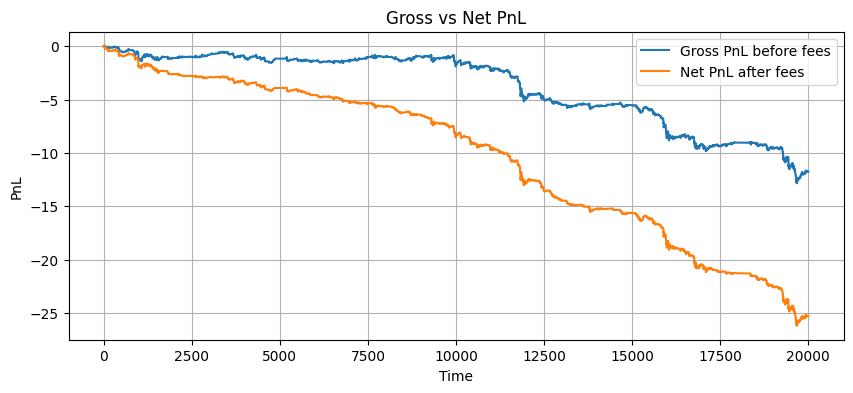

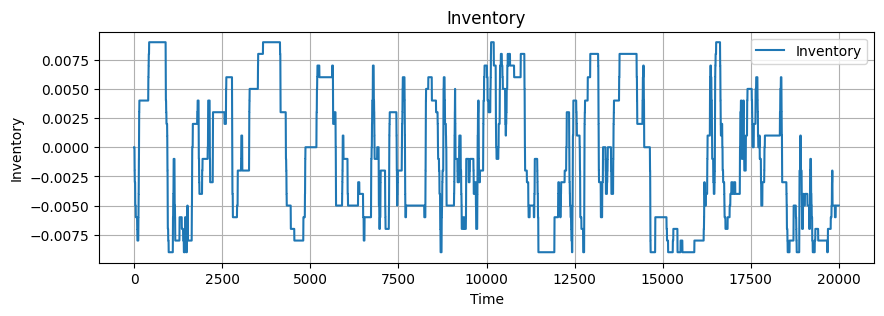

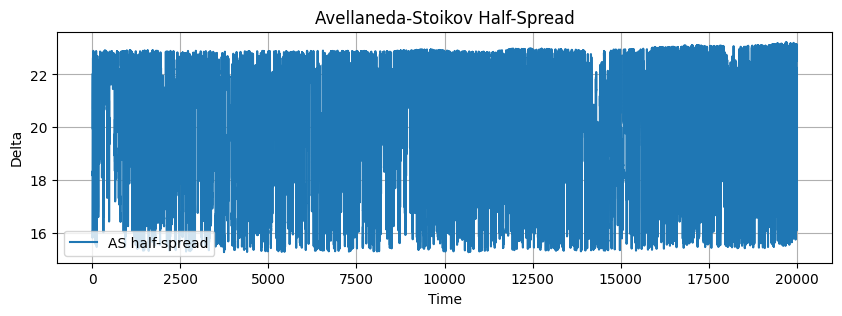

In [120]:
# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(df_profitable["gross_pnl_before_fees"], label="Gross PnL before fees")
plt.plot(df_profitable["pnl"], label="Net PnL after fees")
plt.title("Gross vs Net PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(df_profitable["inventory"], label="Inventory")
plt.title("Inventory")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(df_profitable["delta_as"], label="AS half-spread")
plt.title("Avellaneda-Stoikov Half-Spread")
plt.xlabel("Time")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

In [97]:
# ============================================================
# Diagnostics
# ============================================================

pnl_change_std = df_profitable["pnl_change"].std()

if pnl_change_std > 0:
    sharpe = (
        df_profitable["pnl_change"].mean()
        / pnl_change_std
        * np.sqrt(len(df_profitable))
    )
else:
    sharpe = np.nan

gross_drawdown = (
    df_profitable["gross_pnl_before_fees"].cummax()
    - df_profitable["gross_pnl_before_fees"]
).max()

net_drawdown = (
    df_profitable["pnl"].cummax()
    - df_profitable["pnl"]
).max()

n_trades = df_profitable["trade"].abs().sum() / df_profitable.attrs["qty"]
total_fees = df_profitable["fee"].sum()
gross_final_pnl = df_profitable["gross_pnl_before_fees"].iloc[-1]
net_final_pnl = df_profitable["pnl"].iloc[-1]

print()
print("Gross final PnL before fees:", gross_final_pnl)
print("Gross max drawdown before fees:", gross_drawdown)
print("Net final PnL after fees:", net_final_pnl)
print("Net max drawdown after fees:", net_drawdown)
print("Sharpe:", sharpe)
print("Final inventory:", df_profitable["inventory"].iloc[-1])
print("Max inventory:", df_profitable["inventory"].abs().max())
print("Number of trades:", n_trades)
print("Total fees:", total_fees)
print()
if n_trades > 0:
    print("Gross PnL per trade:", gross_final_pnl / n_trades)
    print("Net PnL per trade:", net_final_pnl / n_trades)
    print("Average fee per trade:", total_fees / n_trades)
print()
print("Mean bid execution probability:", df_profitable["p_bid_exec"].mean())
print("Mean ask execution probability:", df_profitable["p_ask_exec"].mean())
print("Sigma threshold used:", df_profitable.attrs["sigma_threshold"])
print("Average delta_as:", df_profitable["delta_as"].mean())
print("Average full quoted spread:", 2 * df_profitable["delta_as"].mean())


Gross final PnL before fees: 7.944215000000195
Gross max drawdown before fees: 0.6599949999999952
Net final PnL after fees: 4.156299420000195
Net max drawdown after fees: 0.8942130199999951
Sharpe: 3.8504298043688565
Final inventory: 0.001
Max inventory: 0.005
Number of trades: 233.0
Total fees: 3.787915580000001

Gross PnL per trade: 0.03409534334764032
Net PnL per trade: 0.017838194935623157
Average fee per trade: 0.01625714841201717

Mean bid execution probability: 0.022041439538424242
Mean ask execution probability: 0.02628836485856818
Sigma threshold used: 8.618777289714728
Average delta_as: 33.60133436608139
Average full quoted spread: 67.20266873216278


In [98]:
seeds = range(20)

seed_results = []

for seed in seeds:
    df_tmp = avellaneda_profitable_strat(
        df=df,
        lambda_as=lambda_as,
        kappa=kappa,
        k_fill=k_fill,
        p0=p0,
        Qmax=Qmax,
        alpha_imb=alpha_imb,
        alpha_risk=alpha_risk,
        alpha_inventory=alpha_inventory,
        sigma_threshold=None,
        sigma_quantile=0.85,
        c=0.1,
        qty=qty,
        vol_window=100,
        fee_rate=fee_rate,
        tick_size=tick_size,
        min_order_qty=min_order_qty,
        edge_buffer_ticks=2,
        imb_threshold=0.4,
        seed=seed,
    )

    pnl_change_std = df_tmp["pnl_change"].std()
    sharpe_seed = (
        df_tmp["pnl_change"].mean() / pnl_change_std * np.sqrt(len(df_tmp))
        if pnl_change_std > 0 else np.nan
    )

    seed_results.append({
        "seed": seed,
        "final_pnl": df_tmp["pnl"].iloc[-1],
        "sharpe": sharpe_seed,
        "max_drawdown": (df_tmp["pnl"].cummax() - df_tmp["pnl"]).max(),
        "max_inventory": df_tmp["inventory"].abs().max(),
        "n_trades": df_tmp["trade"].abs().sum() / df_tmp.attrs["qty"],
        "total_fees": df_tmp["fee"].sum(),
    })

seed_results_df = pd.DataFrame(seed_results)
seed_results_df.describe()

Starting improved Avellaneda-Stoikov simulation...


Simulating strategy: 100%|██████████| 5000/5000 [00:18<00:00, 266.87it/s]


Starting improved Avellaneda-Stoikov simulation...


Simulating strategy: 100%|██████████| 5000/5000 [00:15<00:00, 327.39it/s]


Starting improved Avellaneda-Stoikov simulation...


...

Starting improved Avellaneda-Stoikov simulation...


Simulating strategy: 100%|██████████| 5000/5000 [00:20<00:00, 250.00it/s]


Starting improved Avellaneda-Stoikov simulation...


Simulating strategy: 100%|██████████| 5000/5000 [00:20<00:00, 249.13it/s]


,seed,final_pnl,sharpe,max_drawdown,max_inventory,n_trades,total_fees
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.50000,3.943469,2.832301,1.042631,0.006750,227.850000,3.647192
std,5.91608,1.162928,0.977210,0.353953,0.000851,21.590142,0.340756
min,0.00000,0.779244,0.667389,0.515581,0.005000,186.000000,2.993179
25%,4.75000,3.078157,2.019465,0.829097,0.006000,215.000000,3.421596
50%,9.50000,4.106846,3.071101,1.002131,0.007000,225.500000,3.640666
75%,14.25000,4.832728,3.291882,1.079629,0.007000,240.750000,3.854318
max,19.00000,5.879597,4.908811,1.894411,0.009000,274.000000,4.271794


In [3]:
import pandas as pd
df_large=df = pd.read_csv("../data/raw/Largebookticker.csv")
df_large["volume"] = df_large["best_bid_qty"] + df_large["best_ask_qty"]
df_large.head()

,timestamp,symbol,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty,mid_price,spread,volume
0,2026-04-28 21:34:52.132676+00:00,BTCUSDT,76327.67,1.78717,76327.68,2.17814,76327.675,0.01,3.96531
1,2026-04-28 21:34:53.420398+00:00,BTCUSDT,76327.67,1.78717,76327.68,2.17789,76327.675,0.01,3.96506
2,2026-04-28 21:34:54.700675+00:00,BTCUSDT,76327.67,1.78635,76327.68,2.17049,76327.675,0.01,3.95684
3,2026-04-28 21:34:55.976833+00:00,BTCUSDT,76327.67,1.78635,76327.68,2.17241,76327.675,0.01,3.95876
4,2026-04-28 21:34:57.280770+00:00,BTCUSDT,76327.67,1.78920,76327.68,2.09017,76327.675,0.01,3.87937


In [102]:
df_profitable_large = avellaneda_profitable_strat(
    df=df_large,
    lambda_as=lambda_as,
    kappa=kappa,
    k_fill=k_fill,
    p0=p0,
    Qmax=Qmax,
    alpha_imb=alpha_imb,
    alpha_risk=alpha_risk,
    alpha_inventory=alpha_inventory,
    sigma_threshold=None,
    sigma_quantile=0.85,
    c=0.1,
    qty=qty,
    vol_window=100,
    fee_rate=fee_rate,
    tick_size=tick_size,
    min_order_qty=min_order_qty,
    edge_buffer_ticks=2,
    imb_threshold=0.4,
    seed=42,
)

Starting improved Avellaneda-Stoikov simulation...


Simulating strategy:   0%|          | 0/20000 [00:00<?, ?it/s]

Simulating strategy: 100%|██████████| 20000/20000 [01:06<00:00, 301.05it/s]


In [106]:
# ============================================================
# Diagnostics
# ============================================================

pnl_change_std = df_profitable_large["pnl_change"].std()

if pnl_change_std > 0:
    raw_sharpe = (
        df_profitable_large["pnl_change"].mean()
        / pnl_change_std
        * np.sqrt(len(df_profitable_large))
    )
else:
    raw_sharpe = np.nan
seconds_per_year = 365 * 24 * 60 * 60
annualized_sharpe = raw_sharpe * np.sqrt(seconds_per_year)

gross_drawdown = (
    df_profitable_large["gross_pnl_before_fees"].cummax()
    - df_profitable_large["gross_pnl_before_fees"]
).max()

net_drawdown = (
    df_profitable_large["pnl"].cummax()
    - df_profitable_large["pnl"]
).max()

n_trades = df_profitable_large["trade"].abs().sum() / df_profitable_large.attrs["qty"]
total_fees = df_profitable_large["fee"].sum()
gross_final_pnl = df_profitable_large["gross_pnl_before_fees"].iloc[-1]
net_final_pnl = df_profitable_large["pnl"].iloc[-1]

print()
print("Gross final PnL before fees:", gross_final_pnl)
print("Gross max drawdown before fees:", gross_drawdown)
print("Net final PnL after fees:", net_final_pnl)
print("Net max drawdown after fees:", net_drawdown)
print("Sharpe:", annualized_sharpe)
print("Final inventory:", df_profitable_large["inventory"].iloc[-1])
print("Max inventory:", df_profitable_large["inventory"].abs().max())
print("Number of trades:", n_trades)
print("Total fees:", total_fees)
print()
if n_trades > 0:
    print("Gross PnL per trade:", gross_final_pnl / n_trades)
    print("Net PnL per trade:", net_final_pnl / n_trades)
    print("Average fee per trade:", total_fees / n_trades)
print()
print("Mean bid execution probability:", df_profitable_large["p_bid_exec"].mean())
print("Mean ask execution probability:", df_profitable_large["p_ask_exec"].mean())
print("Sigma threshold used:", df_profitable_large.attrs["sigma_threshold"])
print("Average delta_as:", df_profitable_large["delta_as"].mean())
print("Average full quoted spread:", 2 * df_profitable_large["delta_as"].mean())


Gross final PnL before fees: 32.81219999999969
Gross max drawdown before fees: 0.8767600000000471
Net final PnL after fees: 18.802766279999688
Net max drawdown after fees: 0.8865666600000282
Sharpe: 67502.81175241659
Final inventory: 0.0
Max inventory: 0.008
Number of trades: 892.0
Total fees: 14.00943372

Gross PnL per trade: 0.036784977578474994
Net PnL per trade: 0.021079334394618485
Average fee per trade: 0.0157056431838565

Mean bid execution probability: 0.02183280639906131
Mean ask execution probability: 0.02373525253140435
Sigma threshold used: 3.7998360876386577
Average delta_as: 34.35323947087958
Average full quoted spread: 68.70647894175916


In [107]:
df_tmp = df_profitable_large.copy()
df_tmp["timestamp"] = pd.to_datetime(df_tmp["timestamp"])
df_tmp = df_tmp.set_index("timestamp")

# PnL sampled every 1 minute
pnl_1min = df_tmp["pnl"].resample("1min").last().ffill()
pnl_change_1min = pnl_1min.diff().dropna()

raw_sharpe_1min = pnl_change_1min.mean() / pnl_change_1min.std()

print("Raw 1-minute Sharpe:", raw_sharpe_1min)

Raw 1-minute Sharpe: 0.4638867968536488


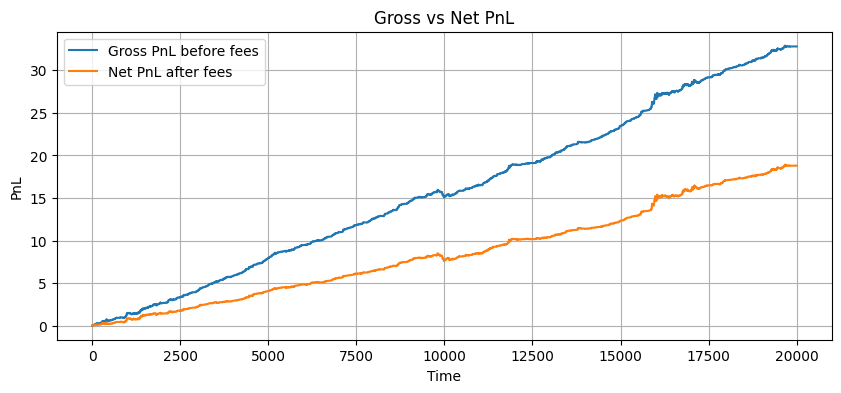

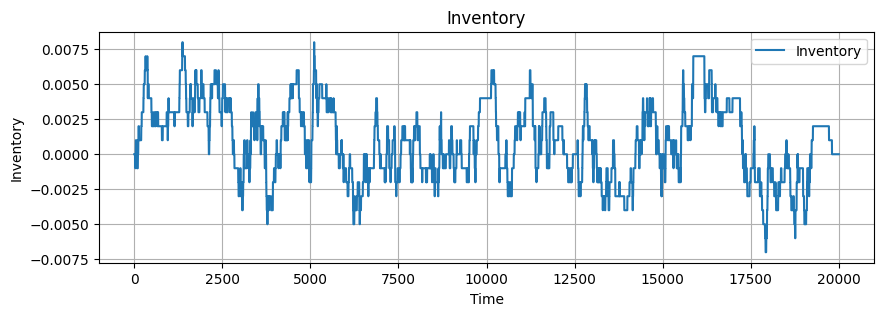

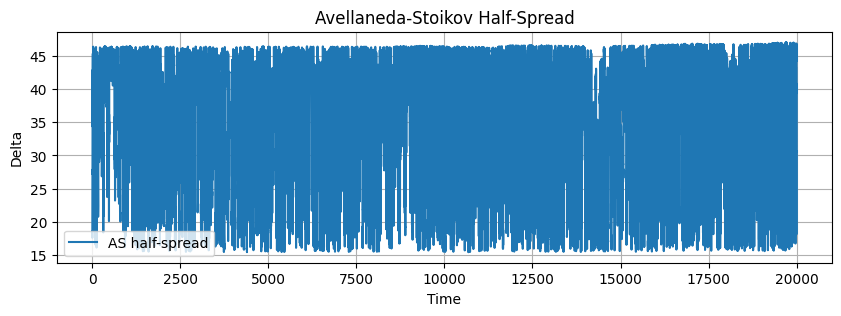

In [110]:
# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(df_profitable_large["gross_pnl_before_fees"], label="Gross PnL before fees")
plt.plot(df_profitable_large["pnl"], label="Net PnL after fees")
plt.title("Gross vs Net PnL")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(df_profitable_large["inventory"], label="Inventory")
plt.title("Inventory")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(df_profitable_large["delta_as"], label="AS half-spread")
plt.title("Avellaneda-Stoikov Half-Spread")
plt.xlabel("Time")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()